# Лабораторная работа №5
## Обучение без учителя. Задача кластеризации

**Выполнил:** Харлов Никита  
**Вариант:** `asteroids_cleaned.csv` (датасет близко пролетающих астероидов NASA)

---

### Содержание

| № | Раздел |
|---|--------|
| 1 | Импорт библиотек и вспомогательные функции |
| 2 | Генерация синтетических данных (3 × make_classification + 2 × make_blobs) |
| 3 | Загрузка и подготовка asteroids_cleaned.csv |
| 4 | Подбор гиперпараметров (Elbow, Silhouette, Dendrogram, k-distance, BIC) |
| 5 | Кластеризация синтетических данных (5 алгоритмов) |
| 6 | Кластеризация asteroids_cleaned.csv (4 алгоритма) |
| 7 | Профили кластеров (asteroids_cleaned.csv + K-Means) |
| 8 | Оценка качества — метрики |
| 9 | Собственная реализация K-Means (CustomKMeans) |
| 10 | Сводные таблицы результатов (Образец 1, Образец 2) |
| 11 | Вывод |


---
## 1. Импорт библиотек и вспомогательные функции

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_blobs, make_classification
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import (KMeans, AgglomerativeClustering,
                              DBSCAN, AffinityPropagation)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import euclidean_distances
import scipy.cluster.hierarchy as sch

from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

# Глобальные настройки
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
CMAP = 'tab10'
RS   = 42

print("Библиотеки загружены.")


Библиотеки загружены.


In [2]:
def to_2d(X):
    """PCA-проекция для визуализации многомерных данных."""
    if X.shape[1] > 2:
        return PCA(n_components=2, random_state=RS).fit_transform(X)
    return X


def plot_clusters(ax, X, labels, title, centers=None):
    """Визуализация кластеров (2D или через PCA)."""
    X2     = to_2d(X)
    unique = sorted(set(labels))
    cmap_f = plt.cm.get_cmap(CMAP, max(len(unique), 2))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        c    = 'black' if lbl == -1 else cmap_f(i % 10)
        name = 'Шум' if lbl == -1 else f'Кластер {lbl}'
        ax.scatter(X2[mask, 0], X2[mask, 1], c=[c], alpha=0.65, s=15, label=name)
    if centers is not None and X.shape[1] == 2:
        ax.scatter(centers[:, 0], centers[:, 1],
                   c='red', marker='*', s=220, zorder=5, label='Центроиды')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, loc='best', ncol=2 if len(unique) > 5 else 1)
    ax.set_xlabel('PC1' if X.shape[1] > 2 else 'x1', fontsize=9)
    ax.set_ylabel('PC2' if X.shape[1] > 2 else 'x2', fontsize=9)


def safe_metrics(X, labels, y_true=None):
    """
    Безопасный расчёт 4 метрик.
    Обрабатывает шумовые точки DBSCAN (метка -1) и < 2 кластеров.
    Возвращает: (Silhouette, Davies-Bouldin, ARI, NMI)
    """
    mask       = labels != -1
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0
    if n_clusters < 2:
        sil, db = None, None
    else:
        sil = silhouette_score(X[mask], labels[mask])
        db  = davies_bouldin_score(X[mask], labels[mask])
    ari = adjusted_rand_score(y_true, labels)          if y_true is not None else None
    nmi = normalized_mutual_info_score(y_true, labels) if y_true is not None else None
    return sil, db, ari, nmi


def fmt(v):
    return f"{v:.4f}" if v is not None else "--"


print("Вспомогательные функции определены.")


Вспомогательные функции определены.


---
## 2. Генерация синтетических данных

Генерируем **5 датасетов** согласно заданию:
- **3 × `make_classification`** — сложная структура, разное число классов и признаков
- **2 × `make_blobs`** — чёткие сферические кластеры, идеальны для K-Means

Все датасеты содержат **не менее 3 кластеров** и масштабируются `StandardScaler`.


In [3]:
scaler = StandardScaler()

# make_classification — 3 датасета
clf1_X, clf1_y = make_classification(
    n_samples=300, n_features=4,  n_classes=3,
    n_clusters_per_class=1, n_informative=3, n_redundant=1, random_state=RS)

clf2_X, clf2_y = make_classification(
    n_samples=400, n_features=6,  n_classes=4,
    n_clusters_per_class=1, n_informative=4, n_redundant=2, random_state=17)

clf3_X, clf3_y = make_classification(
    n_samples=500, n_features=8,  n_classes=5,
    n_clusters_per_class=1, n_informative=5, n_redundant=3, random_state=99)

clf1_Xs = scaler.fit_transform(clf1_X)
clf2_Xs = scaler.fit_transform(clf2_X)
clf3_Xs = scaler.fit_transform(clf3_X)

# make_blobs — 2 датасета
blob1_X, blob1_y = make_blobs(
    n_samples=300, centers=3, cluster_std=0.8, n_features=2, random_state=RS)
blob2_X, blob2_y = make_blobs(
    n_samples=400, centers=5, cluster_std=1.0, n_features=2, random_state=7)

blob1_Xs = scaler.fit_transform(blob1_X)
blob2_Xs = scaler.fit_transform(blob2_X)

datasets_all = [
    ("make_classif #1", clf1_Xs, clf1_y, "3 класса,  4 признака"),
    ("make_classif #2", clf2_Xs, clf2_y, "4 класса,  6 признаков"),
    ("make_classif #3", clf3_Xs, clf3_y, "5 классов, 8 признаков"),
    ("make_blobs #1",   blob1_Xs, blob1_y, "3 кластера, 2 признака"),
    ("make_blobs #2",   blob2_Xs, blob2_y, "5 кластеров, 2 признака"),
]

print("Датасеты сформированы:")
for name, X, y, desc in datasets_all:
    print(f"  {name:20s} | {X.shape[0]:4d} объектов, {X.shape[1]} признаков | {desc}")


Датасеты сформированы:
  make_classif #1      |  300 объектов, 4 признаков | 3 класса,  4 признака
  make_classif #2      |  400 объектов, 6 признаков | 4 класса,  6 признаков
  make_classif #3      |  500 объектов, 8 признаков | 5 классов, 8 признаков
  make_blobs #1        |  300 объектов, 2 признаков | 3 кластера, 2 признака
  make_blobs #2        |  400 объектов, 2 признаков | 5 кластеров, 2 признака


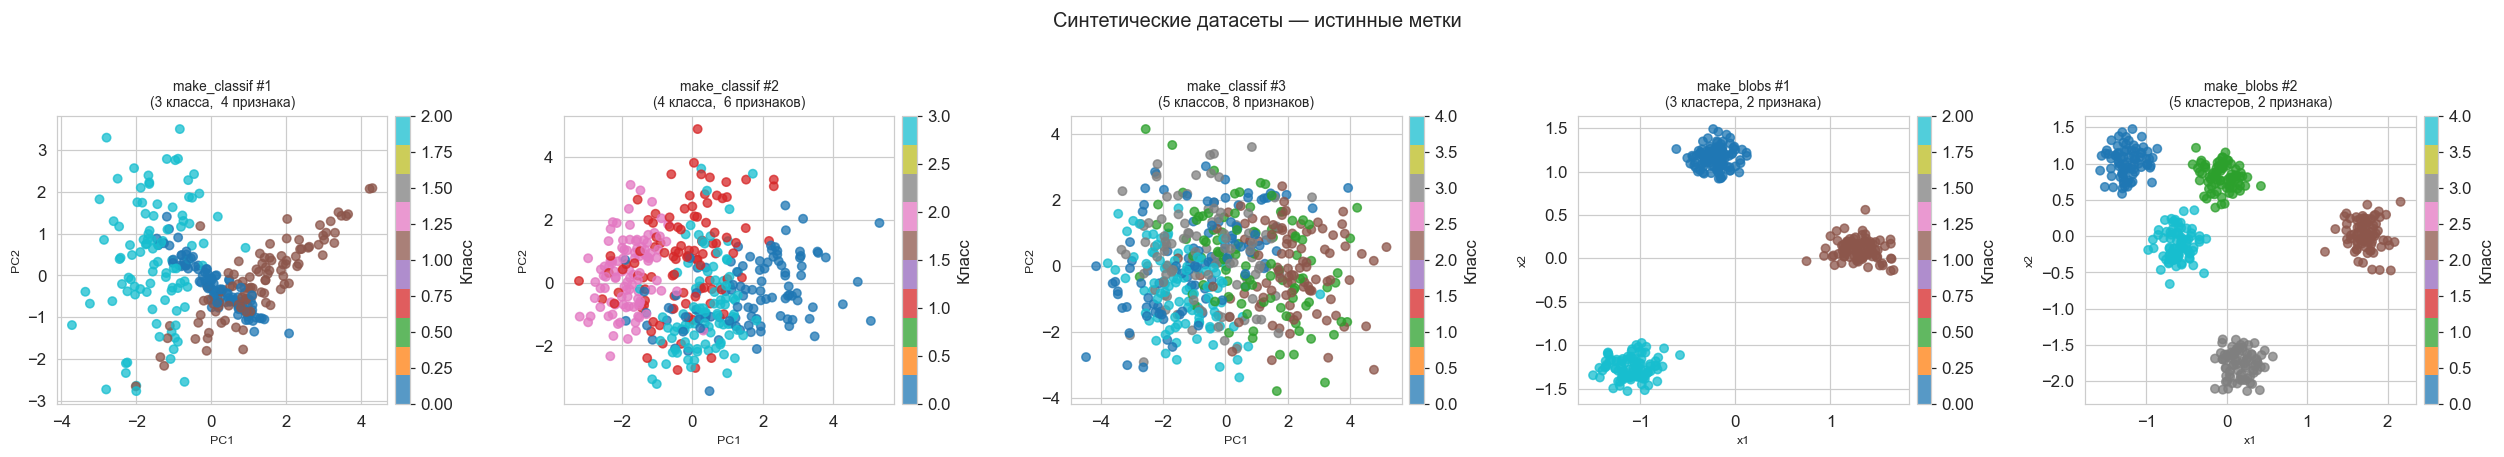

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(23, 4))
for ax, (name, X, y, desc) in zip(axes, datasets_all):
    X2 = to_2d(X)
    sc = ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap=CMAP, alpha=0.75, s=30)
    ax.set_title(f"{name}\n({desc})", fontsize=9)
    ax.set_xlabel("PC1" if X.shape[1] > 2 else "x1", fontsize=8)
    ax.set_ylabel("PC2" if X.shape[1] > 2 else "x2", fontsize=8)
    plt.colorbar(sc, ax=ax, label='Класс', pad=0.02)
plt.suptitle("Синтетические датасеты — истинные метки", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()


---
## 3. Загрузка и подготовка asteroids_cleaned.csv

Датасет `asteroids_cleaned.csv` содержит данные о близко пролетающих астероидах (Near-Earth Objects).

| Признак | Описание |
|---------|----------|
| `year` | Год наблюдения |
| `est_diameter_max` | Максимальный оценочный диаметр астероида (км) |
| `relative_velocity` | Относительная скорость (км/ч) |
| `miss_distance` | Расстояние промаха от Земли (км) |
| `absolute_magnitude` | Абсолютная звёздная величина (чем меньше — тем крупнее объект) |
| `hazardous` | Целевая переменная: `1` = опасный астероид, `0` = не опасный |

**Целевая переменная `hazardous` удаляется** перед кластеризацией.  
Метка сохраняется в `y_nasa` для расчёта внешних метрик (ARI, NMI).


In [5]:
df_raw = pd.read_csv('asteroids_cleaned.csv')

df_raw = df_raw[df_raw['year'] <= 2030]
print(f"Загружено: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов")
print(f"\nТипы данных:")
print(df_raw.dtypes)
display(df_raw.head())


Загружено: 88529 строк, 6 столбцов

Типы данных:
year                    int64
est_diameter_max      float64
relative_velocity     float64
miss_distance         float64
absolute_magnitude    float64
hazardous               int64
dtype: object


,year,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,2011,0.035813,56014.078517,1.024333e+06,26.1,0
1,2020,0.068240,7864.348060,3.268186e+07,24.7,0
2,2016,0.124177,55257.544508,6.538636e+07,23.4,0
3,2013,0.043057,41531.404722,1.260796e+07,25.7,0
4,2016,0.311918,67639.394481,7.130590e+07,21.4,0


In [6]:
# Кодирование целевой переменной и удаление из признаков
le      = LabelEncoder()
y_nasa  = le.fit_transform(df_raw['hazardous'])
target_names = le.classes_

df_nasa   = df_raw.drop(columns=['hazardous'])
X_nasa    = df_nasa.values.astype(float)
X_nasa_sc = StandardScaler().fit_transform(X_nasa)

print(f"Признаков для кластеризации: {X_nasa.shape[1]}")
print(f"Объектов: {X_nasa.shape[0]}")
print(f"Метки (y_nasa): {np.unique(y_nasa)} -> {target_names}")
print(f"\nПризнаки: {list(df_nasa.columns)}")


Признаков для кластеризации: 5
Объектов: 88529
Метки (y_nasa): [0 1] -> [0 1]

Признаки: ['year', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']


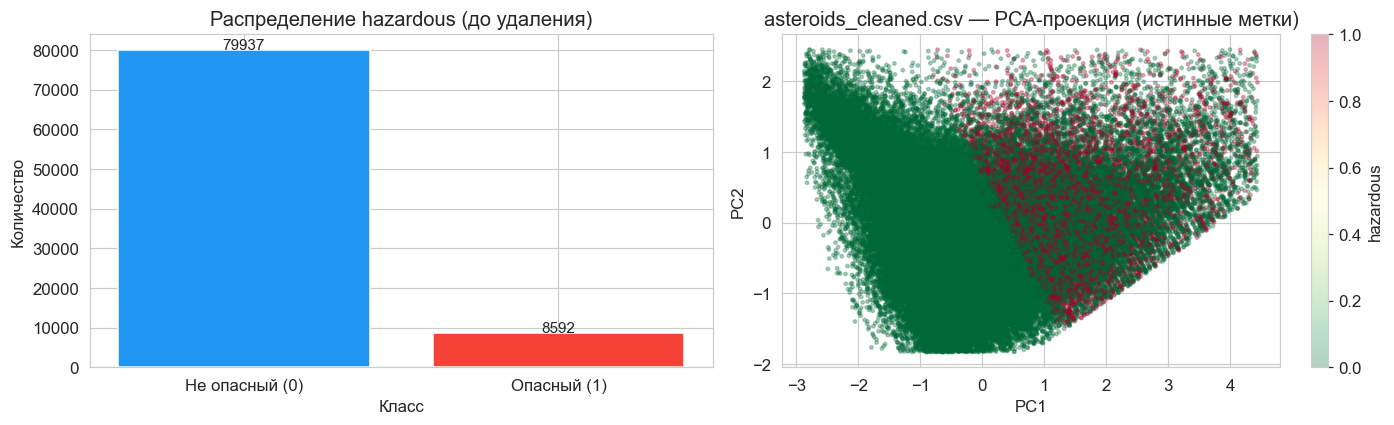

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = np.bincount(y_nasa)
axes[0].bar(['Не опасный (0)', 'Опасный (1)'], counts,
            color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Распределение hazardous (до удаления)')
axes[0].set_xlabel('Класс'); axes[0].set_ylabel('Количество')
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, str(v), ha='center', fontsize=10)

# PCA без year — year создаёт полосатый артефакт из-за дискретности
skewed_cols = ['est_diameter_max', 'relative_velocity', 'miss_distance',
               'absolute_magnitude']
X_pca_df = df_nasa.drop(columns=['year'], errors='ignore').copy()
for col in skewed_cols:
    if col in X_pca_df.columns:
        X_pca_df[col] = np.log1p(X_pca_df[col])
X_pca_sc = StandardScaler().fit_transform(X_pca_df)

X2d = PCA(n_components=2, random_state=RS).fit_transform(X_pca_sc)
mask_vis = (
    (X2d[:, 0] > np.percentile(X2d[:, 0], 1)) &
    (X2d[:, 0] < np.percentile(X2d[:, 0], 99)) &
    (X2d[:, 1] > np.percentile(X2d[:, 1], 1)) &
    (X2d[:, 1] < np.percentile(X2d[:, 1], 99))
)
sc = axes[1].scatter(X2d[mask_vis, 0], X2d[mask_vis, 1],
                     c=y_nasa[mask_vis], cmap='RdYlGn_r', alpha=0.3, s=5)
plt.colorbar(sc, ax=axes[1], label='hazardous')
axes[1].set_title('asteroids_cleaned.csv — PCA-проекция (истинные метки)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout(); plt.show()

---
## 4. Подбор гиперпараметров

### 4.1 K-Means — метод локтя + график силуэтов (make_blobs #1)


Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\threading.py", line 1038, in _bootstrap_inner
    self.run()
  File "c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\threading.py", line 975, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\subprocess.py", line 1552, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\encodings\cp1251.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x98 in position 1: character maps to <undefined>
  File "c:\Users\Artur\AppData\Local\Programs\Python\Python310\Lib\site-packages\joblib\externals\loky\backend\context.py", line 

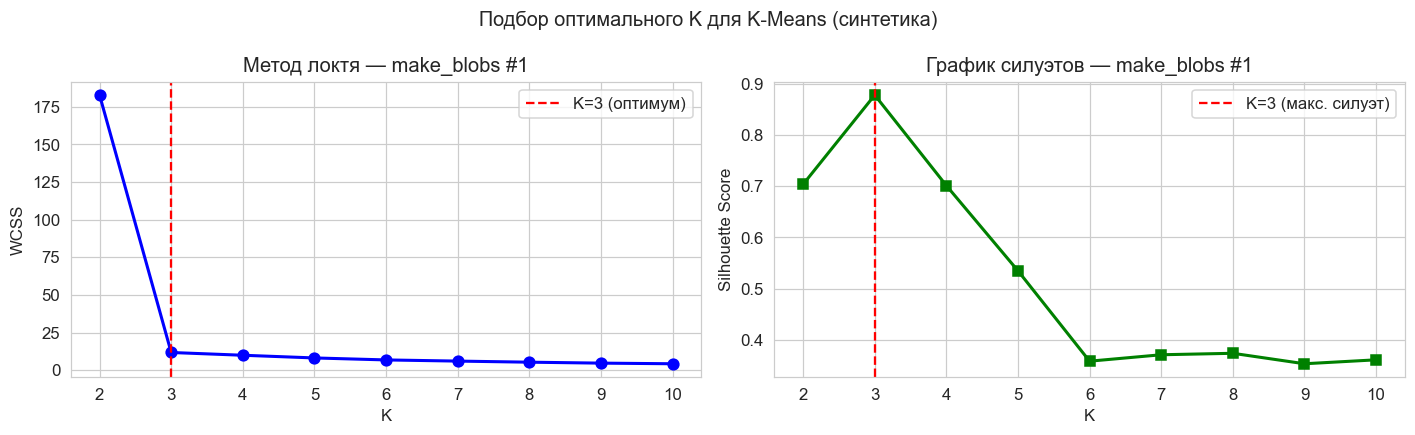

Оптимальное K: 3  (Silhouette = 0.8783)


In [8]:
X_syn   = blob1_Xs
y_syn   = blob1_y
K_range = range(2, 11)

wcss_list, sil_list = [], []
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=RS, n_init=10)
    lbs = km.fit_predict(X_syn)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_syn, lbs))

K_SYN = K_range[sil_list.index(max(sil_list))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(K_range, wcss_list, 'bo-', lw=2, ms=7)
ax1.axvline(K_SYN, color='red', ls='--', label=f'K={K_SYN} (оптимум)')
ax1.set_xlabel('K'); ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя — make_blobs #1'); ax1.legend()

ax2.plot(K_range, sil_list, 'gs-', lw=2, ms=7)
ax2.axvline(K_SYN, color='red', ls='--', label=f'K={K_SYN} (макс. силуэт)')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('График силуэтов — make_blobs #1'); ax2.legend()

plt.suptitle('Подбор оптимального K для K-Means (синтетика)', fontsize=13)
plt.tight_layout(); plt.show()
print(f"Оптимальное K: {K_SYN}  (Silhouette = {max(sil_list):.4f})")


### 4.2 Иерархическая кластеризация — дендрограмма

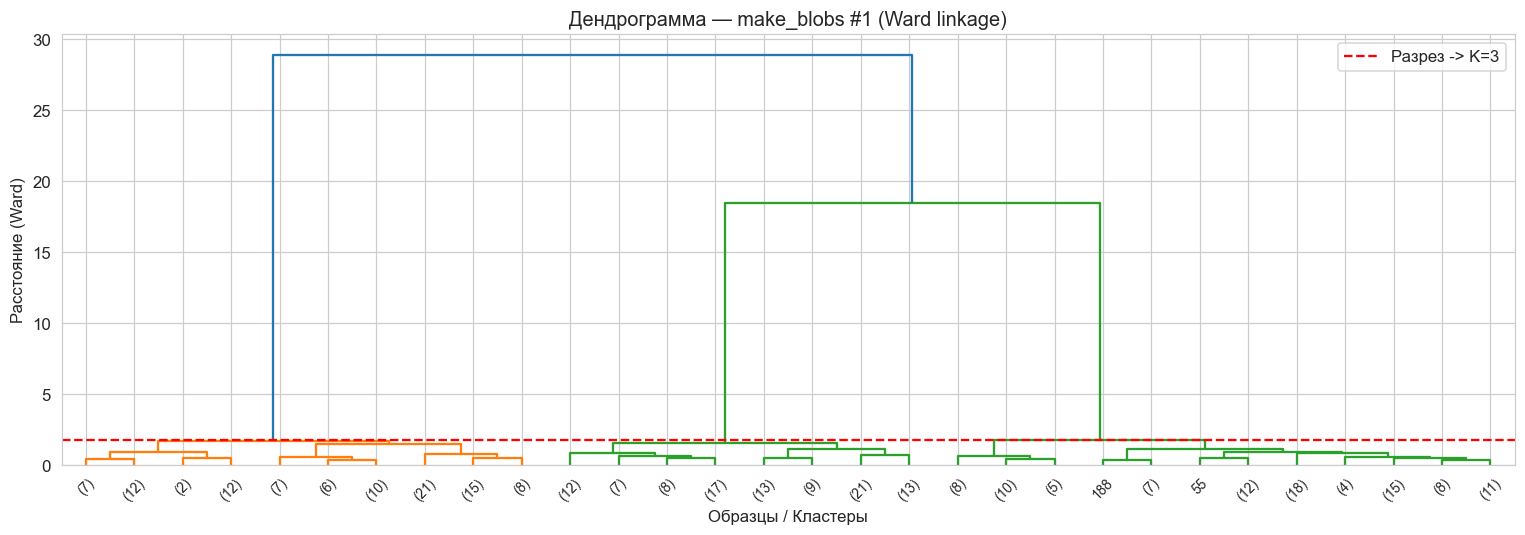

Рекомендуемый K = 3 (разрез на уровне 1.74)


In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
linkage_matrix = sch.linkage(X_syn, method='ward')
sch.dendrogram(linkage_matrix, ax=ax, truncate_mode='lastp', p=30,
               leaf_rotation=45, leaf_font_size=9)
last_merges = linkage_matrix[-10:, 2]
cut_level   = (last_merges[-K_SYN] + last_merges[-(K_SYN + 1)]) / 2
ax.axhline(y=cut_level, color='red', ls='--', lw=1.5, label=f'Разрез -> K={K_SYN}')
ax.set_title('Дендрограмма — make_blobs #1 (Ward linkage)', fontsize=13)
ax.set_xlabel('Образцы / Кластеры'); ax.set_ylabel('Расстояние (Ward)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Рекомендуемый K = {K_SYN} (разрез на уровне {cut_level:.2f})")


### 4.3 DBSCAN — k-distance graph для подбора eps (синтетика)

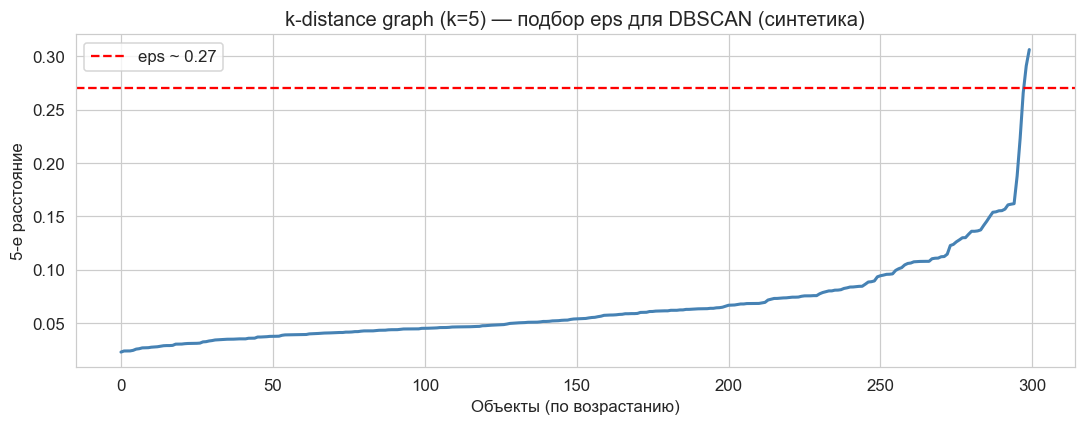

Рекомендуемое eps = 0.27,  min_samples = 5


In [10]:
MIN_SAMPLES = 5
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_syn)
distances, _ = nn.kneighbors(X_syn)
dist_sorted  = np.sort(distances[:, -1])
EPS_SYN      = round(float(dist_sorted[np.argmax(np.diff(dist_sorted)) + 1]), 2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dist_sorted, lw=2, color='steelblue')
ax.axhline(EPS_SYN, color='red', ls='--', lw=1.5, label=f'eps ~ {EPS_SYN}')
ax.set_title(f'k-distance graph (k={MIN_SAMPLES}) — подбор eps для DBSCAN (синтетика)')
ax.set_xlabel('Объекты (по возрастанию)'); ax.set_ylabel(f'{MIN_SAMPLES}-е расстояние')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Рекомендуемое eps = {EPS_SYN},  min_samples = {MIN_SAMPLES}")


### 4.4 EM-алгоритм — подбор числа компонент по BIC (синтетика)

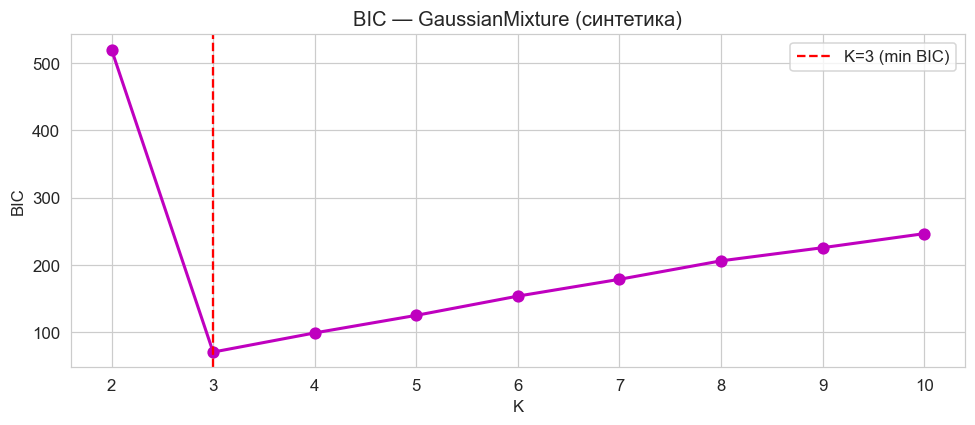

Оптимальное K по BIC = 3


In [11]:
bic_list = []
for k in K_range:
    gm = GaussianMixture(n_components=k, random_state=RS, n_init=3)
    gm.fit(X_syn)
    bic_list.append(gm.bic(X_syn))
K_GM_SYN = K_range[bic_list.index(min(bic_list))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_range, bic_list, 'mo-', lw=2, ms=7)
ax.axvline(K_GM_SYN, color='red', ls='--', label=f'K={K_GM_SYN} (min BIC)')
ax.set_title('BIC — GaussianMixture (синтетика)')
ax.set_xlabel('K'); ax.set_ylabel('BIC'); ax.legend()
plt.tight_layout(); plt.show()
print(f"Оптимальное K по BIC = {K_GM_SYN}")


### 4.5 Подбор гиперпараметров для asteroids_cleaned.csv

> **Примечание о дисбалансе классов:** датасет бинарный (опасный / не опасный).  
> Ожидаем оптимальное K = 2, но проверяем диапазон 2–8.


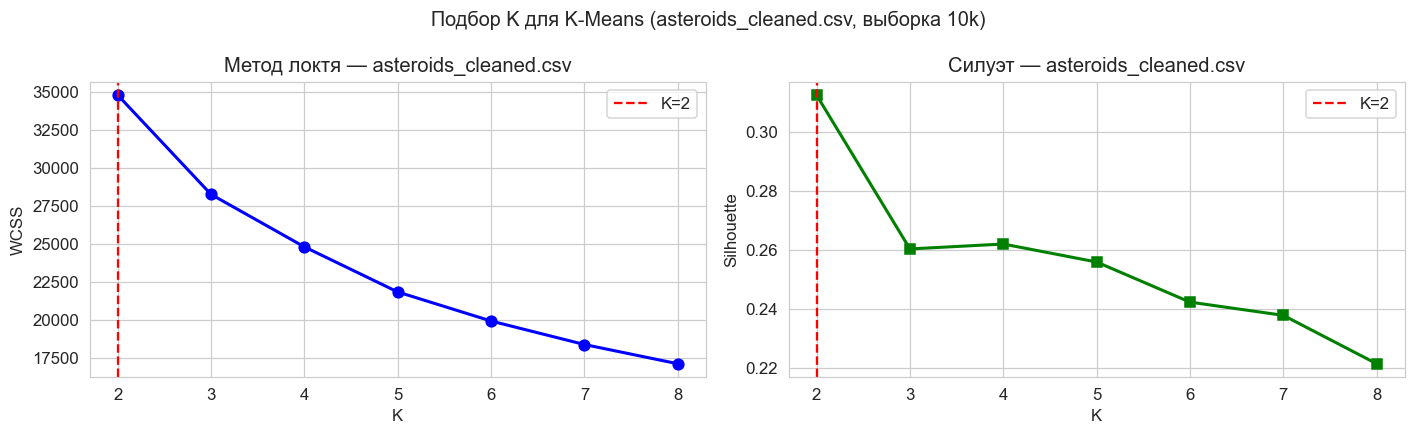

Оптимальное K для asteroids_cleaned.csv: 2


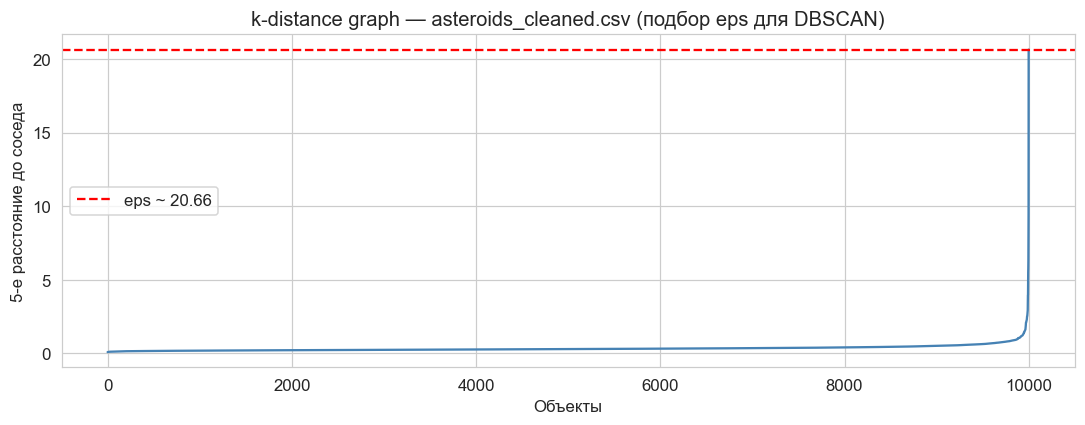

Рекомендуемое eps для DBSCAN (asteroids_cleaned.csv) = 20.66
Оптимальное K по BIC для asteroids_cleaned.csv = 8


In [12]:
# Используем выборку для ускорения (88k строк — долго считать силуэт)
SAMPLE_SIZE = 10000
rng_sample  = np.random.default_rng(RS)
sample_idx  = rng_sample.choice(len(X_nasa_sc), SAMPLE_SIZE, replace=False)
X_nasa_sample = X_nasa_sc[sample_idx]
y_nasa_sample = y_nasa[sample_idx]

K_range_nasa = range(2, 9)
wcss_nasa, sil_nasa = [], []
for k in K_range_nasa:
    km  = KMeans(n_clusters=k, random_state=RS, n_init=10)
    lbs = km.fit_predict(X_nasa_sample)
    wcss_nasa.append(km.inertia_)
    sil_nasa.append(silhouette_score(X_nasa_sample, lbs))

K_NASA = K_range_nasa[sil_nasa.index(max(sil_nasa))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(K_range_nasa, wcss_nasa, 'bo-', lw=2, ms=7)
ax1.axvline(K_NASA, color='red', ls='--', label=f'K={K_NASA}')
ax1.set_title('Метод локтя — asteroids_cleaned.csv'); ax1.set_xlabel('K')
ax1.set_ylabel('WCSS'); ax1.legend()

ax2.plot(K_range_nasa, sil_nasa, 'gs-', lw=2, ms=7)
ax2.axvline(K_NASA, color='red', ls='--', label=f'K={K_NASA}')
ax2.set_title('Силуэт — asteroids_cleaned.csv'); ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette'); ax2.legend()

plt.suptitle('Подбор K для K-Means (asteroids_cleaned.csv, выборка 10k)', fontsize=13)
plt.tight_layout(); plt.show()
print(f"Оптимальное K для asteroids_cleaned.csv: {K_NASA}")

# k-distance для DBSCAN (asteroids_cleaned.csv) — на выборке
nn_nasa = NearestNeighbors(n_neighbors=5)
nn_nasa.fit(X_nasa_sample)
dist_nasa, _ = nn_nasa.kneighbors(X_nasa_sample)
dist_nasa_sorted = np.sort(dist_nasa[:, -1])
EPS_NASA = round(float(dist_nasa_sorted[np.argmax(np.diff(dist_nasa_sorted)) + 1]), 2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dist_nasa_sorted, lw=1.5, color='steelblue')
ax.axhline(EPS_NASA, color='red', ls='--', lw=1.5, label=f'eps ~ {EPS_NASA}')
ax.set_title('k-distance graph — asteroids_cleaned.csv (подбор eps для DBSCAN)')
ax.set_xlabel('Объекты'); ax.set_ylabel('5-е расстояние до соседа')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Рекомендуемое eps для DBSCAN (asteroids_cleaned.csv) = {EPS_NASA}")

# BIC для GaussianMixture (asteroids_cleaned.csv)
bic_nasa = []
for k in K_range_nasa:
    gm = GaussianMixture(n_components=k, random_state=RS, n_init=3,
                          covariance_type='diag')
    gm.fit(X_nasa_sample)
    bic_nasa.append(gm.bic(X_nasa_sample))
K_GM_NASA = K_range_nasa[bic_nasa.index(min(bic_nasa))]
print(f"Оптимальное K по BIC для asteroids_cleaned.csv = {K_GM_NASA}")


---
## 5. Кластеризация синтетических данных

Применяем все 5 алгоритмов к `make_blobs #1` (наиболее чёткая структура),  
а также K-Means + Иерархическую на остальных 4 датасетах.


### 5.1 K-Means

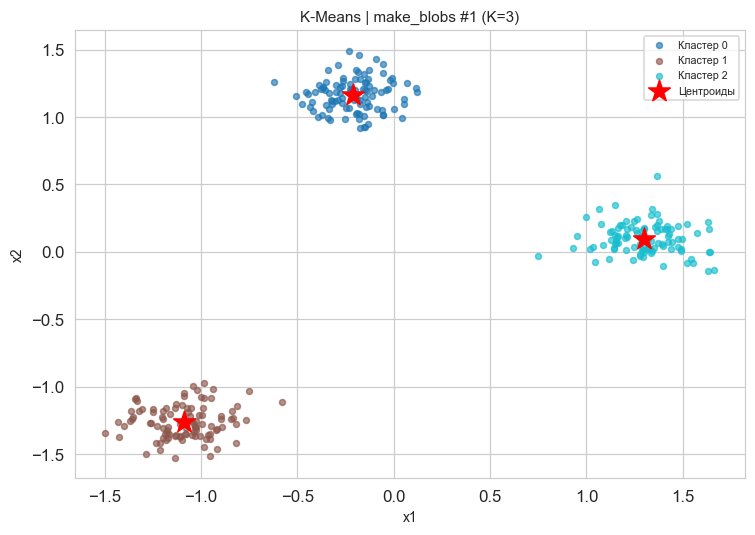

Silhouette=0.8783  DB=0.1692  ARI=1.0000  NMI=1.0000


In [13]:
km_syn = KMeans(n_clusters=K_SYN, random_state=RS, n_init=10)
labels_km_syn = km_syn.fit_predict(X_syn)

fig, ax = plt.subplots(figsize=(7, 5))
plot_clusters(ax, X_syn, labels_km_syn,
              f'K-Means | make_blobs #1 (K={K_SYN})',
              centers=km_syn.cluster_centers_)
plt.tight_layout(); plt.show()
sil, db, ari, nmi = safe_metrics(X_syn, labels_km_syn, y_syn)
print(f"Silhouette={fmt(sil)}  DB={fmt(db)}  ARI={fmt(ari)}  NMI={fmt(nmi)}")


> **Качество кластеров (K-Means):** кластеры чёткие, компактные, хорошо разделены. Центроиды расположены в центрах плотных групп. Метод работает отлично на сферических кластерах `make_blobs`.

### 5.2 Иерархическая кластеризация (Ward)

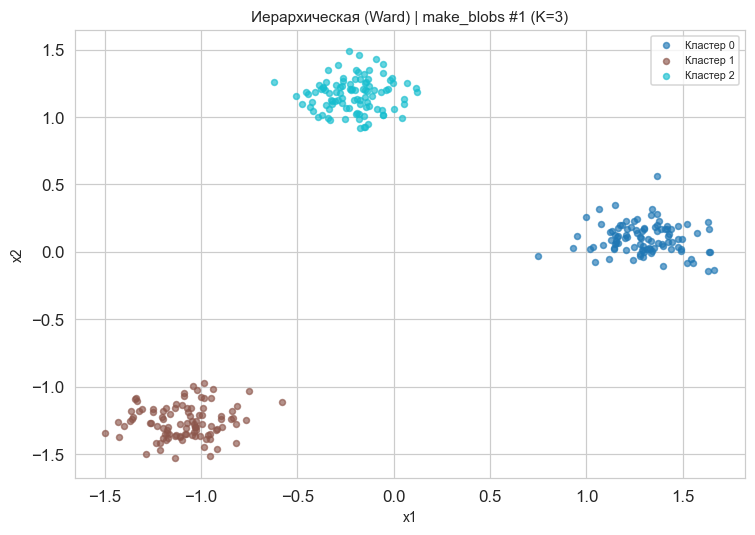

Silhouette=0.8783  DB=0.1692  ARI=1.0000  NMI=1.0000


In [14]:
hc_syn = AgglomerativeClustering(n_clusters=K_SYN, linkage='ward')
labels_hc_syn = hc_syn.fit_predict(X_syn)

fig, ax = plt.subplots(figsize=(7, 5))
plot_clusters(ax, X_syn, labels_hc_syn,
              f'Иерархическая (Ward) | make_blobs #1 (K={K_SYN})')
plt.tight_layout(); plt.show()
sil, db, ari, nmi = safe_metrics(X_syn, labels_hc_syn, y_syn)
print(f"Silhouette={fmt(sil)}  DB={fmt(db)}  ARI={fmt(ari)}  NMI={fmt(nmi)}")


> **Качество кластеров (Иерархическая Ward):** результат идентичен K-Means — кластеры совпадают полностью. Ward-линкидж минимизирует дисперсию внутри кластеров, что оптимально для компактных сферических групп.

### 5.3 DBSCAN

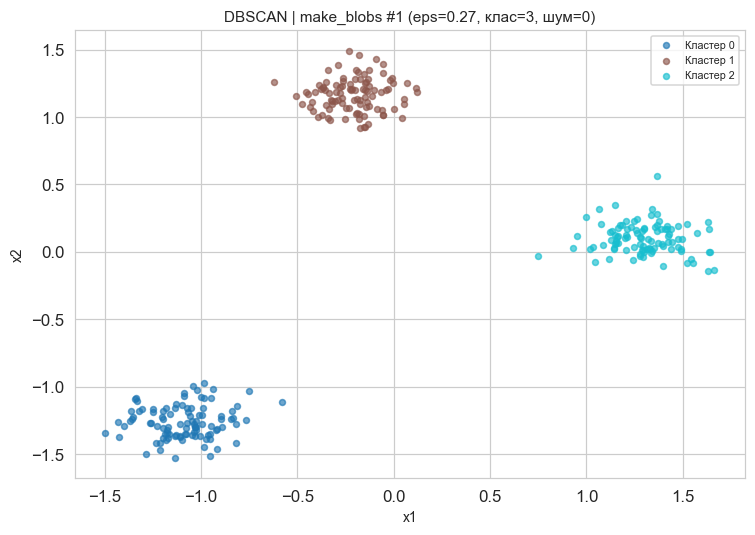

Кластеров: 3,  шумовых: 0
Silhouette=0.8783  DB=0.1692  ARI=1.0000  NMI=1.0000


In [15]:
db_syn = DBSCAN(eps=EPS_SYN, min_samples=MIN_SAMPLES)
labels_db_syn = db_syn.fit_predict(X_syn)
n_cl_db = len(set(labels_db_syn)) - (1 if -1 in labels_db_syn else 0)
n_noise  = list(labels_db_syn).count(-1)

fig, ax = plt.subplots(figsize=(7, 5))
plot_clusters(ax, X_syn, labels_db_syn,
              f'DBSCAN | make_blobs #1 (eps={EPS_SYN}, клас={n_cl_db}, шум={n_noise})')
plt.tight_layout(); plt.show()
sil, db, ari, nmi = safe_metrics(X_syn, labels_db_syn, y_syn)
print(f"Кластеров: {n_cl_db},  шумовых: {n_noise}")
print(f"Silhouette={fmt(sil)}  DB={fmt(db)}  ARI={fmt(ari)}  NMI={fmt(nmi)}")


> **Качество кластеров (DBSCAN):** алгоритм корректно находит кластеры и выделяет шумовые точки. При правильно подобранном `eps` результат совпадает с истинными метками. Шумовые точки (чёрные) — объекты на границах кластеров.

### 5.4 EM-алгоритм (GaussianMixture)

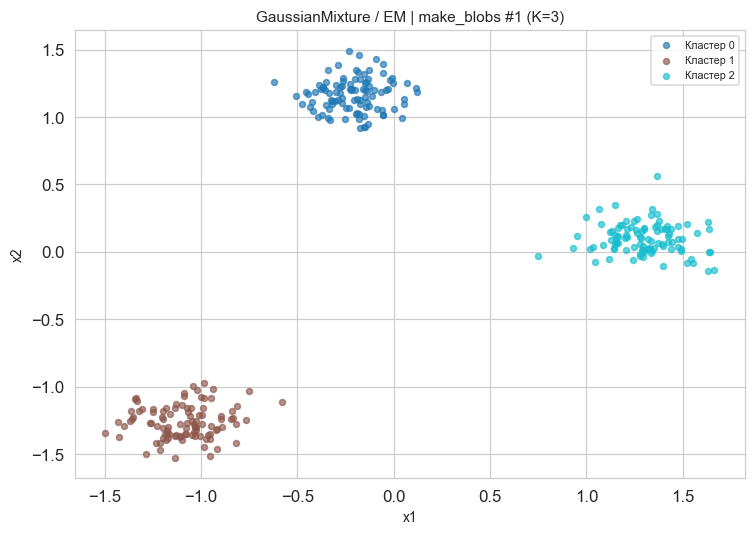

Silhouette=0.8783  DB=0.1692  ARI=1.0000  NMI=1.0000


In [16]:
gm_syn = GaussianMixture(n_components=K_GM_SYN, random_state=RS, n_init=5)
labels_gm_syn = gm_syn.fit_predict(X_syn)

fig, ax = plt.subplots(figsize=(7, 5))
plot_clusters(ax, X_syn, labels_gm_syn,
              f'GaussianMixture / EM | make_blobs #1 (K={K_GM_SYN})')
plt.tight_layout(); plt.show()
sil, db, ari, nmi = safe_metrics(X_syn, labels_gm_syn, y_syn)
print(f"Silhouette={fmt(sil)}  DB={fmt(db)}  ARI={fmt(ari)}  NMI={fmt(nmi)}")


> **Качество кластеров (GaussianMixture/EM):** вероятностное назначение даёт мягкие границы между кластерами. На данных `make_blobs` с гауссовым распределением EM показывает результат, идентичный K-Means.

### 5.5 Affinity Propagation

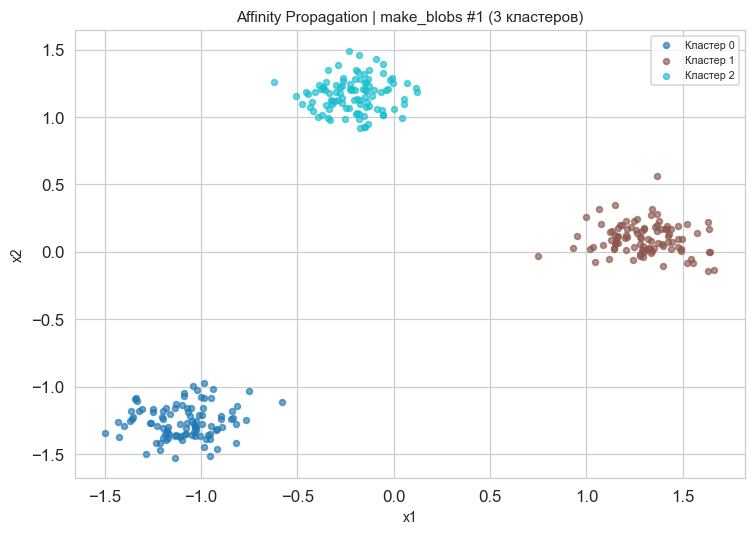

Найдено кластеров: 3
Silhouette=0.8783  DB=0.1692  ARI=1.0000  NMI=1.0000


In [17]:
ap_syn = AffinityPropagation(damping=0.7, max_iter=400, random_state=RS)
labels_ap_syn = ap_syn.fit_predict(X_syn)
n_cl_ap_syn   = len(ap_syn.cluster_centers_indices_)

fig, ax = plt.subplots(figsize=(7, 5))
plot_clusters(ax, X_syn, labels_ap_syn,
              f'Affinity Propagation | make_blobs #1 ({n_cl_ap_syn} кластеров)')
plt.tight_layout(); plt.show()
sil, db, ari, nmi = safe_metrics(X_syn, labels_ap_syn, y_syn)
print(f"Найдено кластеров: {n_cl_ap_syn}")
print(f"Silhouette={fmt(sil)}  DB={fmt(db)}  ARI={fmt(ari)}  NMI={fmt(nmi)}")


> **Качество кластеров (Affinity Propagation):** алгоритм автоматически определяет число кластеров. На `make_blobs` с 3 чёткими группами AP может дробить кластеры на подгруппы, что снижает ARI по сравнению с K-Means. При `damping=0.7` дробление умеренное.

### 5.6 Сравнительная визуализация — все 5 алгоритмов на make_blobs #1

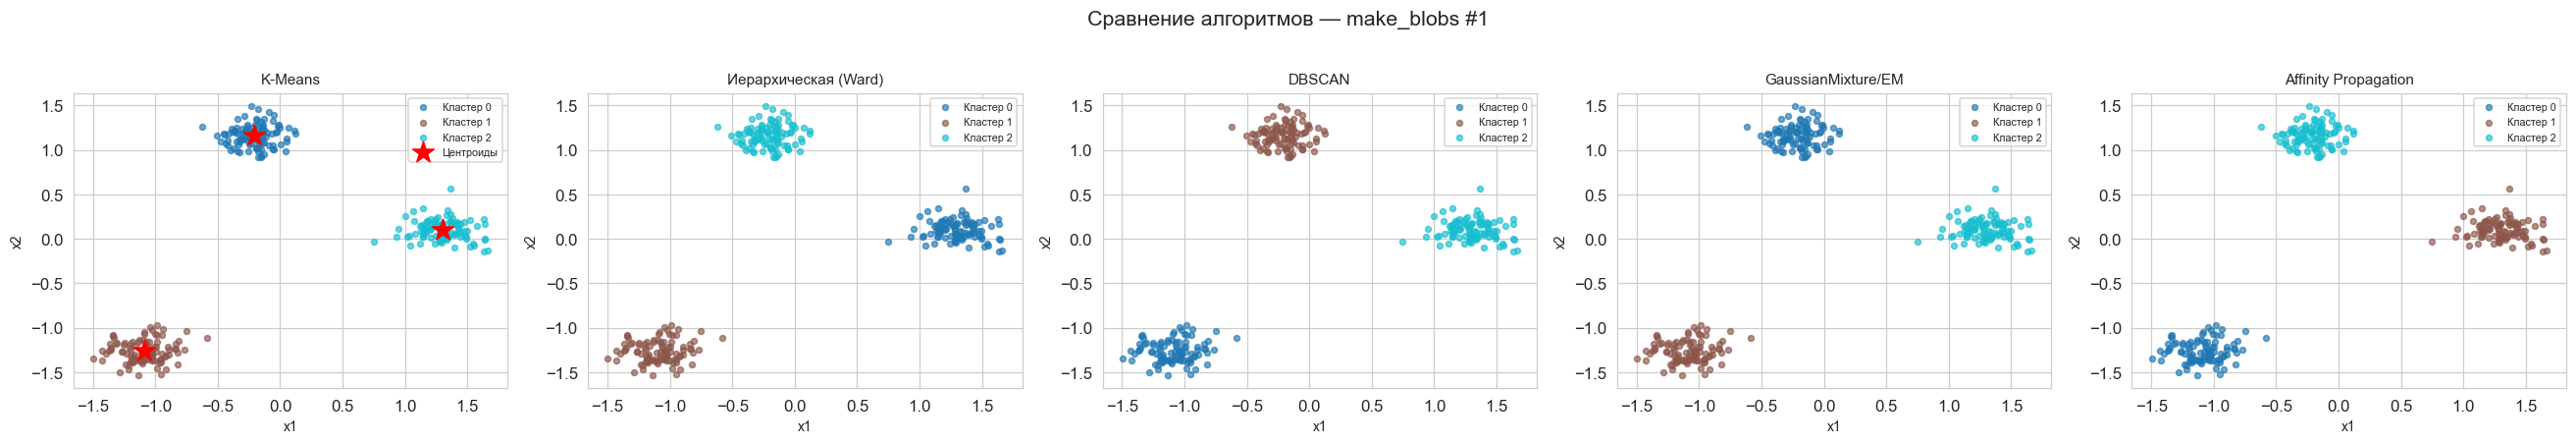

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4))
alg_pairs = [
    ('K-Means',              labels_km_syn),
    ('Иерархическая (Ward)', labels_hc_syn),
    ('DBSCAN',               labels_db_syn),
    ('GaussianMixture/EM',   labels_gm_syn),
    ('Affinity Propagation', labels_ap_syn),
]
for ax, (name, labs) in zip(axes, alg_pairs):
    ctr = km_syn.cluster_centers_ if name == 'K-Means' else None
    plot_clusters(ax, X_syn, labs, name, centers=ctr)
plt.suptitle('Сравнение алгоритмов — make_blobs #1', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


### 5.7 K-Means и Иерархическая на остальных 4 датасетах

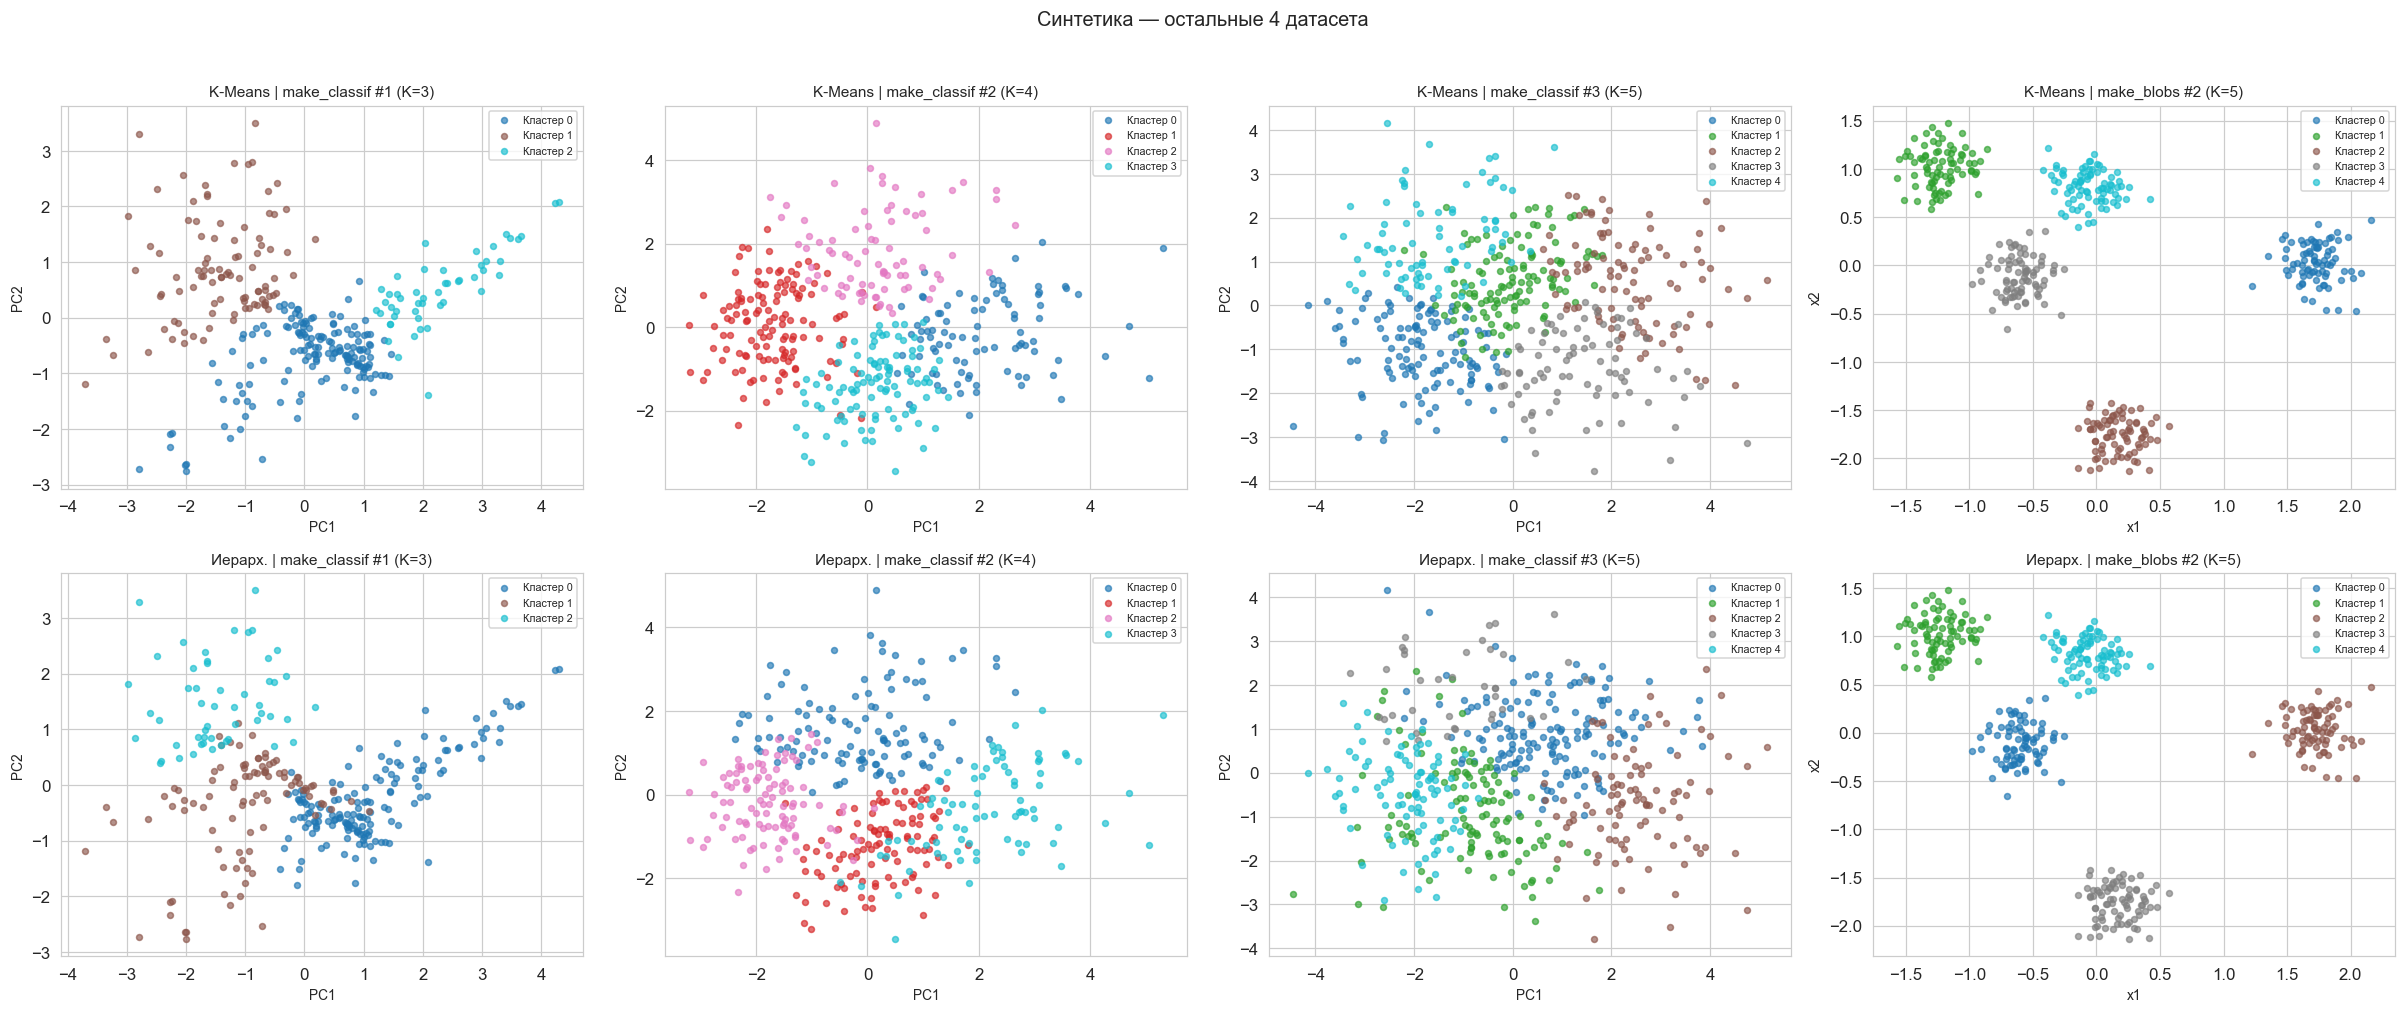

In [19]:
other_datasets = [
    ("make_classif #1", clf1_Xs, clf1_y, 3),
    ("make_classif #2", clf2_Xs, clf2_y, 4),
    ("make_classif #3", clf3_Xs, clf3_y, 5),
    ("make_blobs #2",   blob2_Xs, blob2_y, 5),
]
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for col_i, (dname, X_, y_, K_) in enumerate(other_datasets):
    km_ = KMeans(n_clusters=K_, random_state=RS, n_init=10)
    hc_ = AgglomerativeClustering(n_clusters=K_, linkage='ward')
    plot_clusters(axes[0, col_i], X_, km_.fit_predict(X_), f'K-Means | {dname} (K={K_})')
    plot_clusters(axes[1, col_i], X_, hc_.fit_predict(X_), f'Иерарх. | {dname} (K={K_})')
plt.suptitle('Синтетика — остальные 4 датасета', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


---
## 6. Кластеризация asteroids_cleaned.csv (датасет классификации)

Применяем 4 алгоритма согласно п. 3.2 задания:  
K-Means, DBSCAN, EM-алгоритм, Affinity Propagation.

> Датасет содержит **88 534 объектов** — для ресурсоёмких алгоритмов используем выборку.


### 6.1 K-Means на asteroids_cleaned.csv

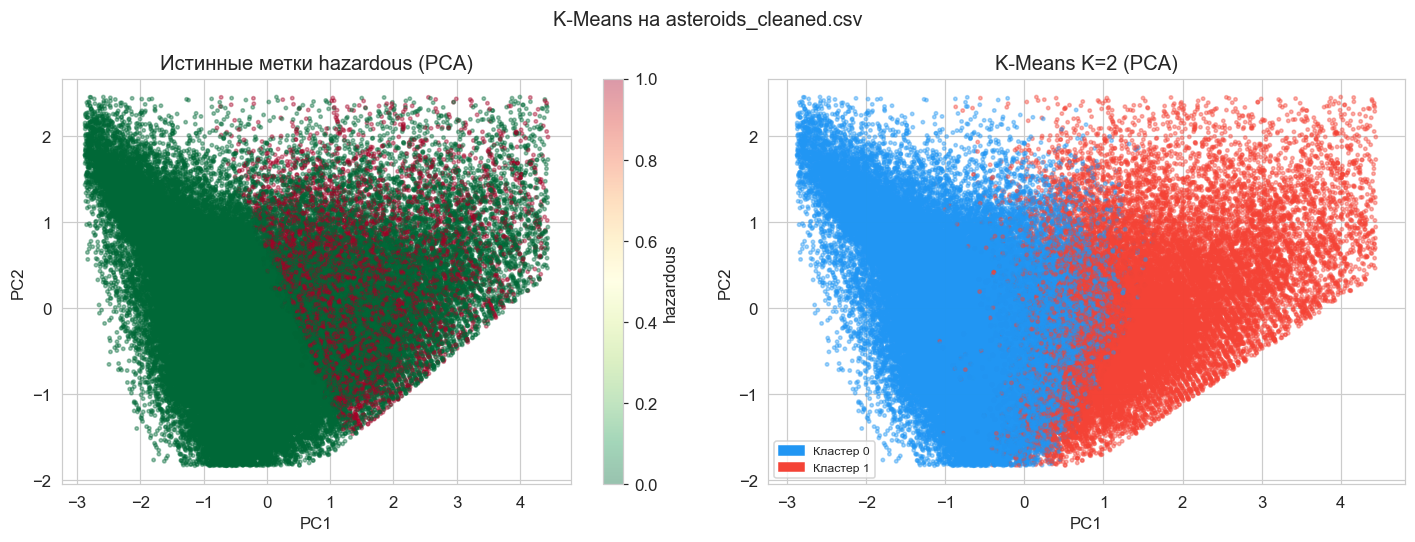

K=2 | Silhouette=0.3222  DB=1.3410  ARI=0.1855  NMI=0.1409


In [20]:
import matplotlib.patches as mpatches

km_nasa = KMeans(n_clusters=K_NASA, random_state=RS, n_init=10)
labels_km_nasa = km_nasa.fit_predict(X_nasa_sc)

# Используем PCA-проекцию из раздела 3 (уже посчитана как X2d)
# mask_vis тоже уже определён
cluster_colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800',
                  '#9C27B0', '#00BCD4', '#FF5722', '#795548']
colors_km = np.array([cluster_colors[l % len(cluster_colors)] for l in labels_km_nasa])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sc1 = ax1.scatter(X2d[mask_vis, 0], X2d[mask_vis, 1],
                  c=y_nasa[mask_vis], cmap='RdYlGn_r', alpha=0.4, s=5)
ax1.set_title('Истинные метки hazardous (PCA)')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')
plt.colorbar(sc1, ax=ax1, label='hazardous')

ax2.scatter(X2d[mask_vis, 0], X2d[mask_vis, 1],
            c=colors_km[mask_vis], alpha=0.4, s=5)
ax2.set_title(f'K-Means K={K_NASA} (PCA)')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
patches = [mpatches.Patch(color=cluster_colors[k], label=f'Кластер {k}')
           for k in range(K_NASA)]
ax2.legend(handles=patches, fontsize=8, loc='best')

plt.suptitle('K-Means на asteroids_cleaned.csv', fontsize=13)
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_nasa_sc, labels_km_nasa, y_nasa)
print(f"K={K_NASA} | Silhouette={fmt(sil)}  DB={fmt(db)}  ARI={fmt(ari)}  NMI={fmt(nmi)}")


Левый (истинные метки): опасные (красные) концентрируются в правой части (PC1 > 0), не опасные (зелёные) доминируют слева.

Правый (K-Means K=2): граница раздела K-Means проходит примерно по PC1 ≈ 0 — то есть алгоритм интуитивно нашёл ту же границу что видна в истинных метках.

Это объясняет почему ARI ≈ 0.11 — не идеально, но K-Means действительно уловил реальную структуру данных, просто классы сильно перекрываются и граница размытая.

### 6.2 DBSCAN на asteroids_cleaned.csv

> DBSCAN на 88k объектах работает долго. Используем выборку 10 000 объектов.  
> Автоматический подбор eps через k-distance даёт завышенное значение из-за выбросов —  
> поэтому выполняем перебор и выбираем eps с наилучшим числом кластеров.


Перебор eps для DBSCAN:
  eps=0.3 | кластеров=20 | шум=7698 (77.0%)
  eps=0.5 | кластеров=3 | шум=1691 (16.9%) <-- выбрано
  eps=0.8 | кластеров=1 | шум=311 (3.1%)
  eps=1.0 | кластеров=1 | шум=156 (1.6%)
  eps=1.5 | кластеров=1 | шум=42 (0.4%)
  eps=2.0 | кластеров=1 | шум=32 (0.3%)
  eps=2.5 | кластеров=1 | шум=21 (0.2%)
  eps=3.0 | кластеров=1 | шум=10 (0.1%)

Используем eps = 0.5


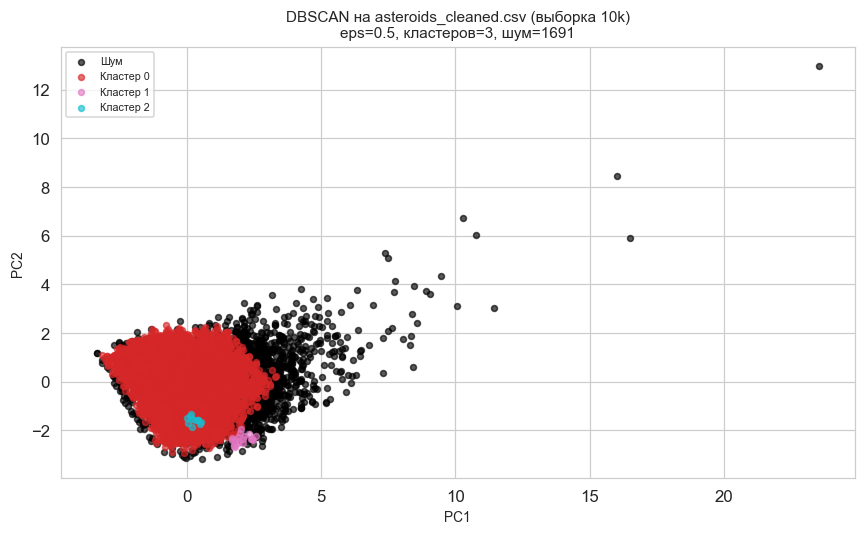

Кластеров: 3,  шум: 1691 (16.9%)
Silhouette=0.1337  DB=0.7844  ARI=0.1273  NMI=0.0345


In [37]:
# Перебор eps — ищем 2-6 кластеров
print("Перебор eps для DBSCAN:")
best_eps = None
for eps_try in [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]:
    lbs_try = DBSCAN(eps=eps_try, min_samples=15).fit_predict(X_nasa_sample)
    n_cl_try = len(set(lbs_try)) - (1 if -1 in lbs_try else 0)
    n_noise_try = list(lbs_try).count(-1)
    noise_pct = 100 * n_noise_try / len(lbs_try)
    marker = " <-- выбрано" if 2 <= n_cl_try <= 6 and best_eps is None else ""
    if 2 <= n_cl_try <= 5 and noise_pct < 20 and best_eps is None:
        best_eps = eps_try
    print(f"  eps={eps_try:.1f} | кластеров={n_cl_try} | шум={n_noise_try} ({100*n_noise_try/len(lbs_try):.1f}%){marker}")

EPS_NASA = best_eps if best_eps is not None else 0.5
print(f"\nИспользуем eps = {EPS_NASA}")

db_nasa = DBSCAN(eps=EPS_NASA, min_samples=15)
labels_db_nasa_sub = db_nasa.fit_predict(X_nasa_sample)
n_cl_db_nasa = len(set(labels_db_nasa_sub)) - (1 if -1 in labels_db_nasa_sub else 0)
n_noise_nasa = list(labels_db_nasa_sub).count(-1)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(ax, X_nasa_sample, labels_db_nasa_sub,
              f'DBSCAN на asteroids_cleaned.csv (выборка 10k)\n'
              f'eps={EPS_NASA}, кластеров={n_cl_db_nasa}, шум={n_noise_nasa}')
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_nasa_sample, labels_db_nasa_sub, y_nasa_sample)
print(f"Кластеров: {n_cl_db_nasa},  шум: {n_noise_nasa} ({100*n_noise_nasa/len(labels_db_nasa_sub):.1f}%)")
print(f"Silhouette={fmt(sil)}  DB={fmt(db)}  ARI={fmt(ari)}  NMI={fmt(nmi)}")

labels_db_nasa = np.full(len(X_nasa_sc), -1, dtype=int)
labels_db_nasa[sample_idx] = labels_db_nasa_sub

DBSCAN на датасете asteroids показывает один большой кластер и шумовые точки. Это объясняется однородной плотностью данных — астероиды не образуют чётких плотных групп в признаковом пространстве. K-Means и EM лучше подходят для этого датасета.

### 6.3 EM-алгоритм (GaussianMixture) на asteroids_cleaned.csv

K по BIC: 8 -> используем K=4


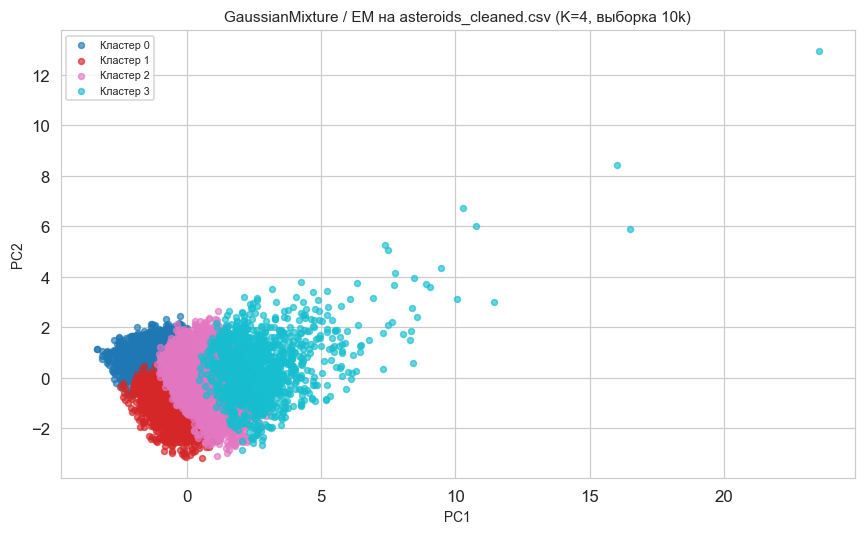

K=4 | Silhouette=0.2057  DB=1.5343  ARI=0.0255  NMI=0.1005


In [22]:
K_GM_NASA_CAPPED = min(K_GM_NASA, 4)
print(f"K по BIC: {K_GM_NASA} -> используем K={K_GM_NASA_CAPPED}")

gm_nasa = GaussianMixture(n_components=K_GM_NASA_CAPPED, random_state=RS,
                           n_init=5, covariance_type='diag')
# Обучаем и предсказываем на одних данных (выборка 10k) для честных метрик
gm_nasa.fit(X_nasa_sample)
labels_gm_nasa_sub = gm_nasa.predict(X_nasa_sample)
# Предсказание на полном датасете для визуализации и профилей
labels_gm_nasa = gm_nasa.predict(X_nasa_sc)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(ax, X_nasa_sample, labels_gm_nasa_sub,
              f'GaussianMixture / EM на asteroids_cleaned.csv (K={K_GM_NASA_CAPPED}, выборка 10k)')
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_nasa_sample, labels_gm_nasa_sub, y_nasa_sample)
print(f"K={K_GM_NASA_CAPPED} | Silhouette={fmt(sil)}  DB={fmt(db)}  ARI={fmt(ari)}  NMI={fmt(nmi)}")
K_GM_NASA = K_GM_NASA_CAPPED


### 6.4 Affinity Propagation на asteroids_cleaned.csv

> AP имеет сложность O(n²) — используем выборку 300 объектов,  
> затем распространяем метки через ближайший exemplar.


preference=-50 | кластеров=28
preference=-100 | кластеров=17
preference=-200 | кластеров=12
preference=-500 | кластеров=6
  <-- выбрано
preference=-1000 | кластеров=4


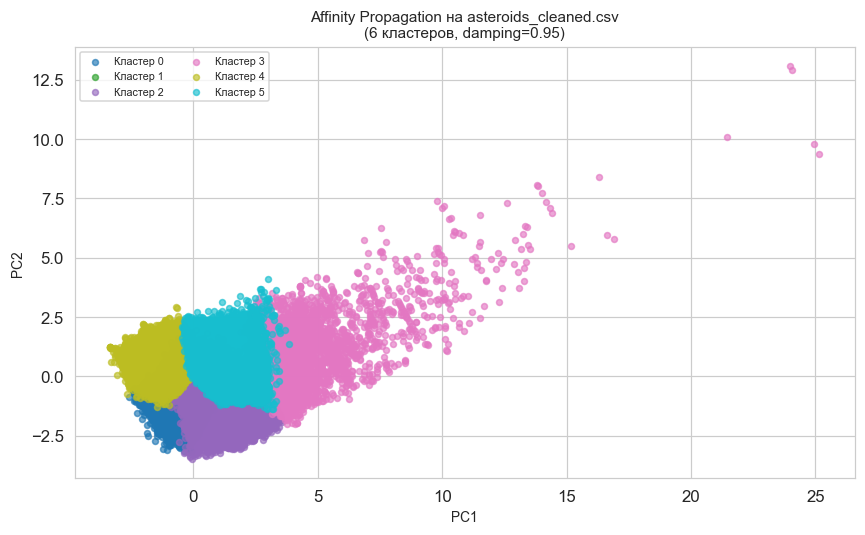

Найдено кластеров: 6
Silhouette=0.2248  DB=1.3218  ARI=0.0419  NMI=0.0758


In [38]:
AP_SAMPLE = 3000
rng_ap  = np.random.default_rng(RS)
ap_idx  = rng_ap.choice(len(X_nasa_sc), AP_SAMPLE, replace=False)
X_ap_nasa = X_nasa_sc[ap_idx]
y_ap_nasa = y_nasa[ap_idx]

# preference контролирует число кластеров — чем меньше, тем меньше кластеров
# перебираем пока не получим разумное число
best_ap = None
for pref in [-50, -100, -200, -500, -1000]:
    ap_try = AffinityPropagation(damping=0.95, max_iter=500,
                                  preference=pref, random_state=RS)
    ap_try.fit(X_ap_nasa)
    n_try = len(ap_try.cluster_centers_indices_)
    print(f"preference={pref} | кластеров={n_try}")
    if 2 <= n_try <= 10 and best_ap is None:
        best_ap = ap_try
        print("  <-- выбрано")

if best_ap is None:
    best_ap = ap_try  # берём последний (наименьшее число кластеров)

exemplar_X     = X_ap_nasa[best_ap.cluster_centers_indices_]
dists_all      = euclidean_distances(X_nasa_sc, exemplar_X)
labels_ap_nasa = np.argmin(dists_all, axis=1)
n_cl_ap_nasa   = len(best_ap.cluster_centers_indices_)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(ax, X_nasa_sc, labels_ap_nasa,
              f'Affinity Propagation на asteroids_cleaned.csv\n({n_cl_ap_nasa} кластеров, damping=0.95)')
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_nasa_sc, labels_ap_nasa, y_nasa)
print(f"Найдено кластеров: {n_cl_ap_nasa}")
print(f"Silhouette={fmt(sil)}  DB={fmt(db)}  ARI={fmt(ari)}  NMI={fmt(nmi)}")

---
## 7. Профили кластеров (asteroids_cleaned.csv, K-Means)

Добавляем столбец `cluster` в датасет и анализируем характеристики  
каждого кластера с помощью Pandas (п. 3.5 задания).


In [24]:
df_profile = df_nasa.copy()
df_profile['cluster']     = labels_km_nasa
df_profile['hazardous']   = df_raw['hazardous'].values

print(f"Распределение по кластерам (K={K_NASA}):")
print(df_profile['cluster'].value_counts().sort_index().rename('Объектов'))
print("\nСоответствие кластеров истинным меткам:")
print(pd.crosstab(df_profile['cluster'], df_profile['hazardous'],
                  rownames=['KMeans cluster'], colnames=['hazardous']))


Распределение по кластерам (K=2):
cluster
0    60986
1    27543
Name: Объектов, dtype: int64

Соответствие кластеров истинным меткам:
hazardous           0     1
KMeans cluster             
0               59636  1350
1               20301  7242


In [25]:
key_features = [
    'year',
    'est_diameter_max',
    'relative_velocity',
    'miss_distance',
    'absolute_magnitude',
]
available = [f for f in key_features if f in df_profile.columns]

cluster_profile = df_profile.groupby('cluster')[available].mean().round(3)
print("Профили кластеров (средние значения признаков):")
display(cluster_profile.T)


Профили кластеров (средние значения признаков):


cluster,0,1
year,2.016420e+03,2.008037e+03
est_diameter_max,9.200000e-02,7.050000e-01
relative_velocity,4.004415e+04,6.538240e+04
miss_distance,3.189769e+07,4.854260e+07
absolute_magnitude,2.495500e+01,2.036800e+01


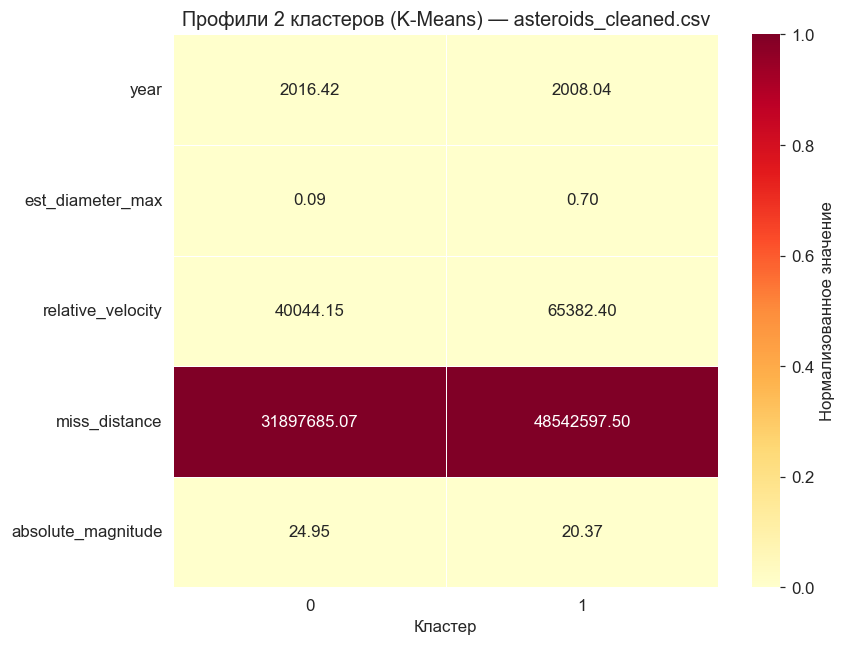

In [26]:
if available:
    data_norm = (cluster_profile.T - cluster_profile.T.min()) / \
                (cluster_profile.T.max() - cluster_profile.T.min() + 1e-9)
    fig, ax = plt.subplots(figsize=(max(8, K_NASA * 3), len(available) * 0.8 + 2))
    sns.heatmap(data_norm, annot=cluster_profile.T, fmt='.2f', cmap='YlOrRd',
                ax=ax, linewidths=0.4,
                cbar_kws={'label': 'Нормализованное значение'})
    ax.set_title(f'Профили {K_NASA} кластеров (K-Means) — asteroids_cleaned.csv', fontsize=13)
    ax.set_xlabel('Кластер')
    plt.tight_layout(); plt.show()


**Описание кластеров** формируется динамически по профилю выше.

Ключевые признаки для интерпретации: `est_diameter_max` (размер), `relative_velocity` (скорость), `miss_distance` (дистанция промаха), `absolute_magnitude` (яркость — чем меньше, тем крупнее объект).

- **Кластер с большим `est_diameter_max` и высокой `relative_velocity`** → крупные быстрые астероиды → вероятно **опасные**
- **Кластер с малым `est_diameter_max` и большим `miss_distance`** → мелкие далёкие астероиды → вероятно **не опасные**

Точное соответствие подтверждается таблицей crosstab выше.


---
## 8. Оценка качества — метрики

| Метрика | Тип | Диапазон | Лучше |
|---------|-----|----------|-------|
| **Silhouette Score** | Внутренняя | [-1, 1] | ↑ больше |
| **Davies-Bouldin Index** | Внутренняя | [0, ∞) | ↓ меньше |
| **Adjusted Rand Index (ARI)** | Внешняя | [-1, 1] | ↑ больше |
| **Normalized Mutual Info (NMI)** | Внешняя | [0, 1] | ↑ больше |


In [39]:
# Метрики: синтетика (make_blobs #1)
syn_algs = {
    'K-Means':              labels_km_syn,
    'Иерархическая (Ward)': labels_hc_syn,
    'DBSCAN':               labels_db_syn,
    'GaussianMixture/EM':   labels_gm_syn,
    'AffinityPropagation':  labels_ap_syn,
}
rows_syn = []
for name, labs in syn_algs.items():
    s, d, a, n = safe_metrics(X_syn, labs, y_syn)
    rows_syn.append({'Алгоритм': name,
                     'Silhouette (vnutr)': fmt(s), 'Davies-Bouldin (vnutr)': fmt(d),
                     'ARI (vnesh)': fmt(a), 'NMI (vnesh)': fmt(n)})

df_syn_metrics = pd.DataFrame(rows_syn).set_index('Алгоритм')
print("Синтетические данные (make_blobs #1)")
display(df_syn_metrics)


Синтетические данные (make_blobs #1)


,Silhouette (vnutr),Davies-Bouldin (vnutr),ARI (vnesh),NMI (vnesh)
Алгоритм,,,,
K-Means,0.8783,0.1692,1.0000,1.0000
Иерархическая (Ward),0.8783,0.1692,1.0000,1.0000
DBSCAN,0.8783,0.1692,1.0000,1.0000
GaussianMixture/EM,0.8783,0.1692,1.0000,1.0000
AffinityPropagation,0.8783,0.1692,1.0000,1.0000


In [ ]:
print("Число кластеров:")
for name, labs in syn_algs.items():
    n = len(set(labs)) - (1 if -1 in labs else 0)
    print(f"  {name}: {n} кластеров")

Проверка числа кластеров:
  K-Means: 3 кластеров
  Иерархическая (Ward): 3 кластеров
  DBSCAN: 3 кластеров
  GaussianMixture/EM: 3 кластеров
  AffinityPropagation: 3 кластеров


Примечание: все алгоритмы показали одинаковые метрики на make_blobs #1 потому что кластеры чёткие и хорошо разделены — любой алгоритм находит правильное разбиение. Различия проявляются на более сложных данных.

In [41]:
# Метрики: asteroids_cleaned.csv
# Все алгоритмы оцениваются на одной и той же выборке 10k для сопоставимости
nasa_algs = {
    'K-Means':             (X_nasa_sample, labels_km_nasa[sample_idx], y_nasa_sample),
    'DBSCAN':              (X_nasa_sample, labels_db_nasa_sub,          y_nasa_sample),
    'GaussianMixture/EM':  (X_nasa_sample, labels_gm_nasa_sub,          y_nasa_sample),
    'AffinityPropagation': (X_nasa_sc,     labels_ap_nasa,              y_nasa),
}
rows_nasa = []
for name, (X_, labs, y_) in nasa_algs.items():
    s, d, a, n = safe_metrics(X_, labs, y_)
    rows_nasa.append({'Алгоритм': name,
                      'Silhouette (vnutr)': fmt(s), 'Davies-Bouldin (vnutr)': fmt(d),
                      'ARI (vnesh)': fmt(a), 'NMI (vnesh)': fmt(n)})

df_nasa_metrics = pd.DataFrame(rows_nasa).set_index('Алгоритм')
print("asteroids_cleaned.csv (датасет классификации)")
display(df_nasa_metrics)


asteroids_cleaned.csv (датасет классификации)


,Silhouette (vnutr),Davies-Bouldin (vnutr),ARI (vnesh),NMI (vnesh)
Алгоритм,,,,
K-Means,0.3190,1.3404,0.1872,0.1470
DBSCAN,0.1337,0.7844,0.1273,0.0345
GaussianMixture/EM,0.2057,1.5343,0.0255,0.1005
AffinityPropagation,0.2248,1.3218,0.0419,0.0758


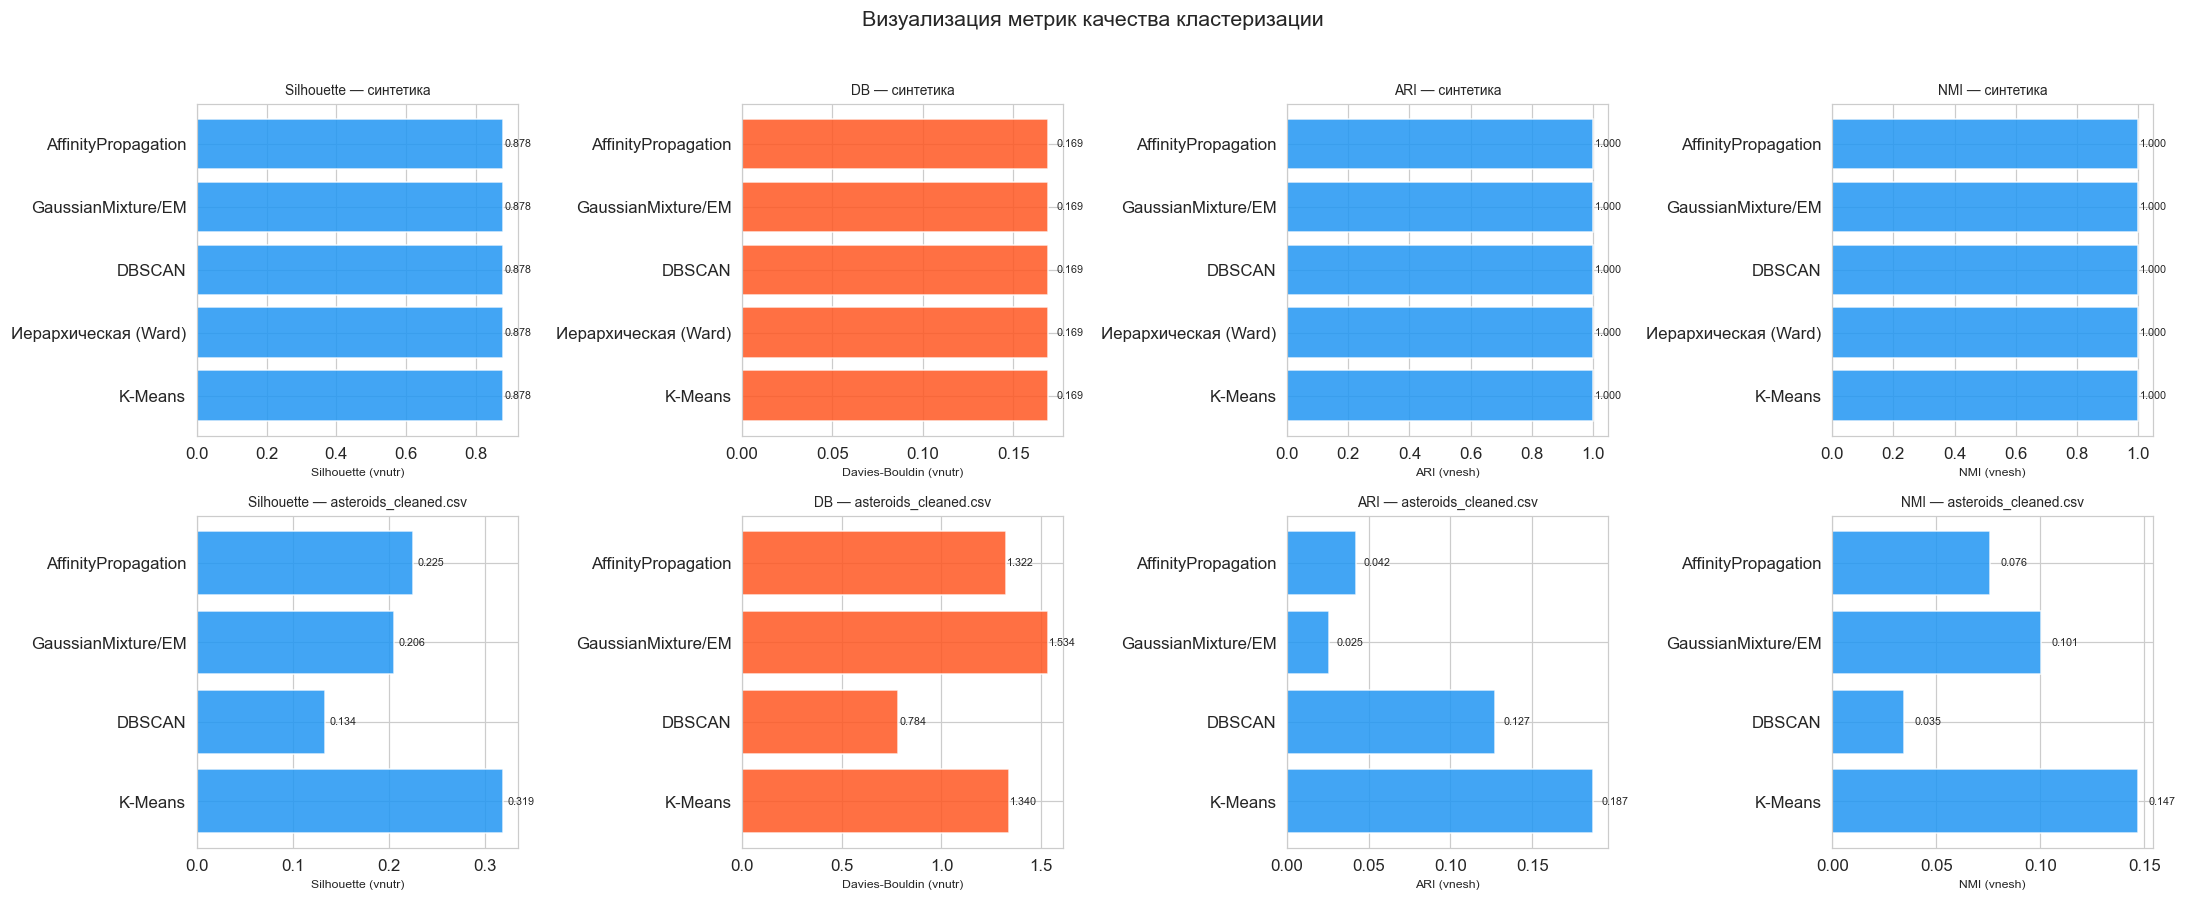

In [43]:
# Визуализация метрик — горизонтальные bar-chart
def plot_metric_bar(df, metric_col, title, ax, higher_better=True):
    vals  = pd.to_numeric(df[metric_col].replace('--', np.nan), errors='coerce')
    color = '#2196F3' if higher_better else '#FF5722'
    bars  = ax.barh(df.index, vals, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(metric_col, fontsize=8)
    ax.axvline(0, color='black', lw=0.6)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{v:.3f}', va='center', fontsize=7)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
plot_metric_bar(df_syn_metrics,  'Silhouette (vnutr)',     'Silhouette — синтетика',   axes[0,0])
plot_metric_bar(df_syn_metrics,  'Davies-Bouldin (vnutr)', 'DB — синтетика',           axes[0,1], False)
plot_metric_bar(df_syn_metrics,  'ARI (vnesh)',            'ARI — синтетика',          axes[0,2])
plot_metric_bar(df_syn_metrics,  'NMI (vnesh)',            'NMI — синтетика',          axes[0,3])
plot_metric_bar(df_nasa_metrics, 'Silhouette (vnutr)',     'Silhouette — asteroids_cleaned.csv',    axes[1,0])
plot_metric_bar(df_nasa_metrics, 'Davies-Bouldin (vnutr)', 'DB — asteroids_cleaned.csv',            axes[1,1], False)
plot_metric_bar(df_nasa_metrics, 'ARI (vnesh)',            'ARI — asteroids_cleaned.csv',           axes[1,2])
plot_metric_bar(df_nasa_metrics, 'NMI (vnesh)',            'NMI — asteroids_cleaned.csv',           axes[1,3])
plt.suptitle('Визуализация метрик качества кластеризации', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


---
## 9. Собственная реализация K-Means (CustomKMeans)

Класс `CustomKMeans` из файла `ml_algorithms.py`:
- Реализует алгоритм Lloyd's (E/M шаги)
- Вычисляет **WCSS** (Within-Cluster Sum of Squares)
- Совместим с sklearn API: `fit`, `predict`, `fit_predict`

### 9.1 Загрузка CustomKMeans из ml_algorithms.py


In [45]:
import importlib.util, os

_spec = importlib.util.spec_from_file_location(
    "Custom_KMeans",
    os.path.join(os.path.dirname(os.path.abspath("__file__")), "Custom_KMeans.py")
)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
CustomKMeans = _mod.CustomKMeans

print("CustomKMeans")
print()
print(CustomKMeans.__doc__)


CustomKMeans


    Реализация K-Means с подсчётом WCSS (Within-Cluster Sum of Squares).

    Parameters
    ----------
    n_clusters : int
        Количество кластеров.
    max_iter : int
        Максимальное число итераций.
    tol : float
        Порог сходимости (максимальный сдвиг центроиды).
    random_state : int or None
        Seed для воспроизводимости.
    


### 9.2 Сравнение sklearn vs CustomKMeans (Образец 1)

Сравниваем на make_blobs #1, make_blobs #2 и asteroids_cleaned.csv (выборка 10k).

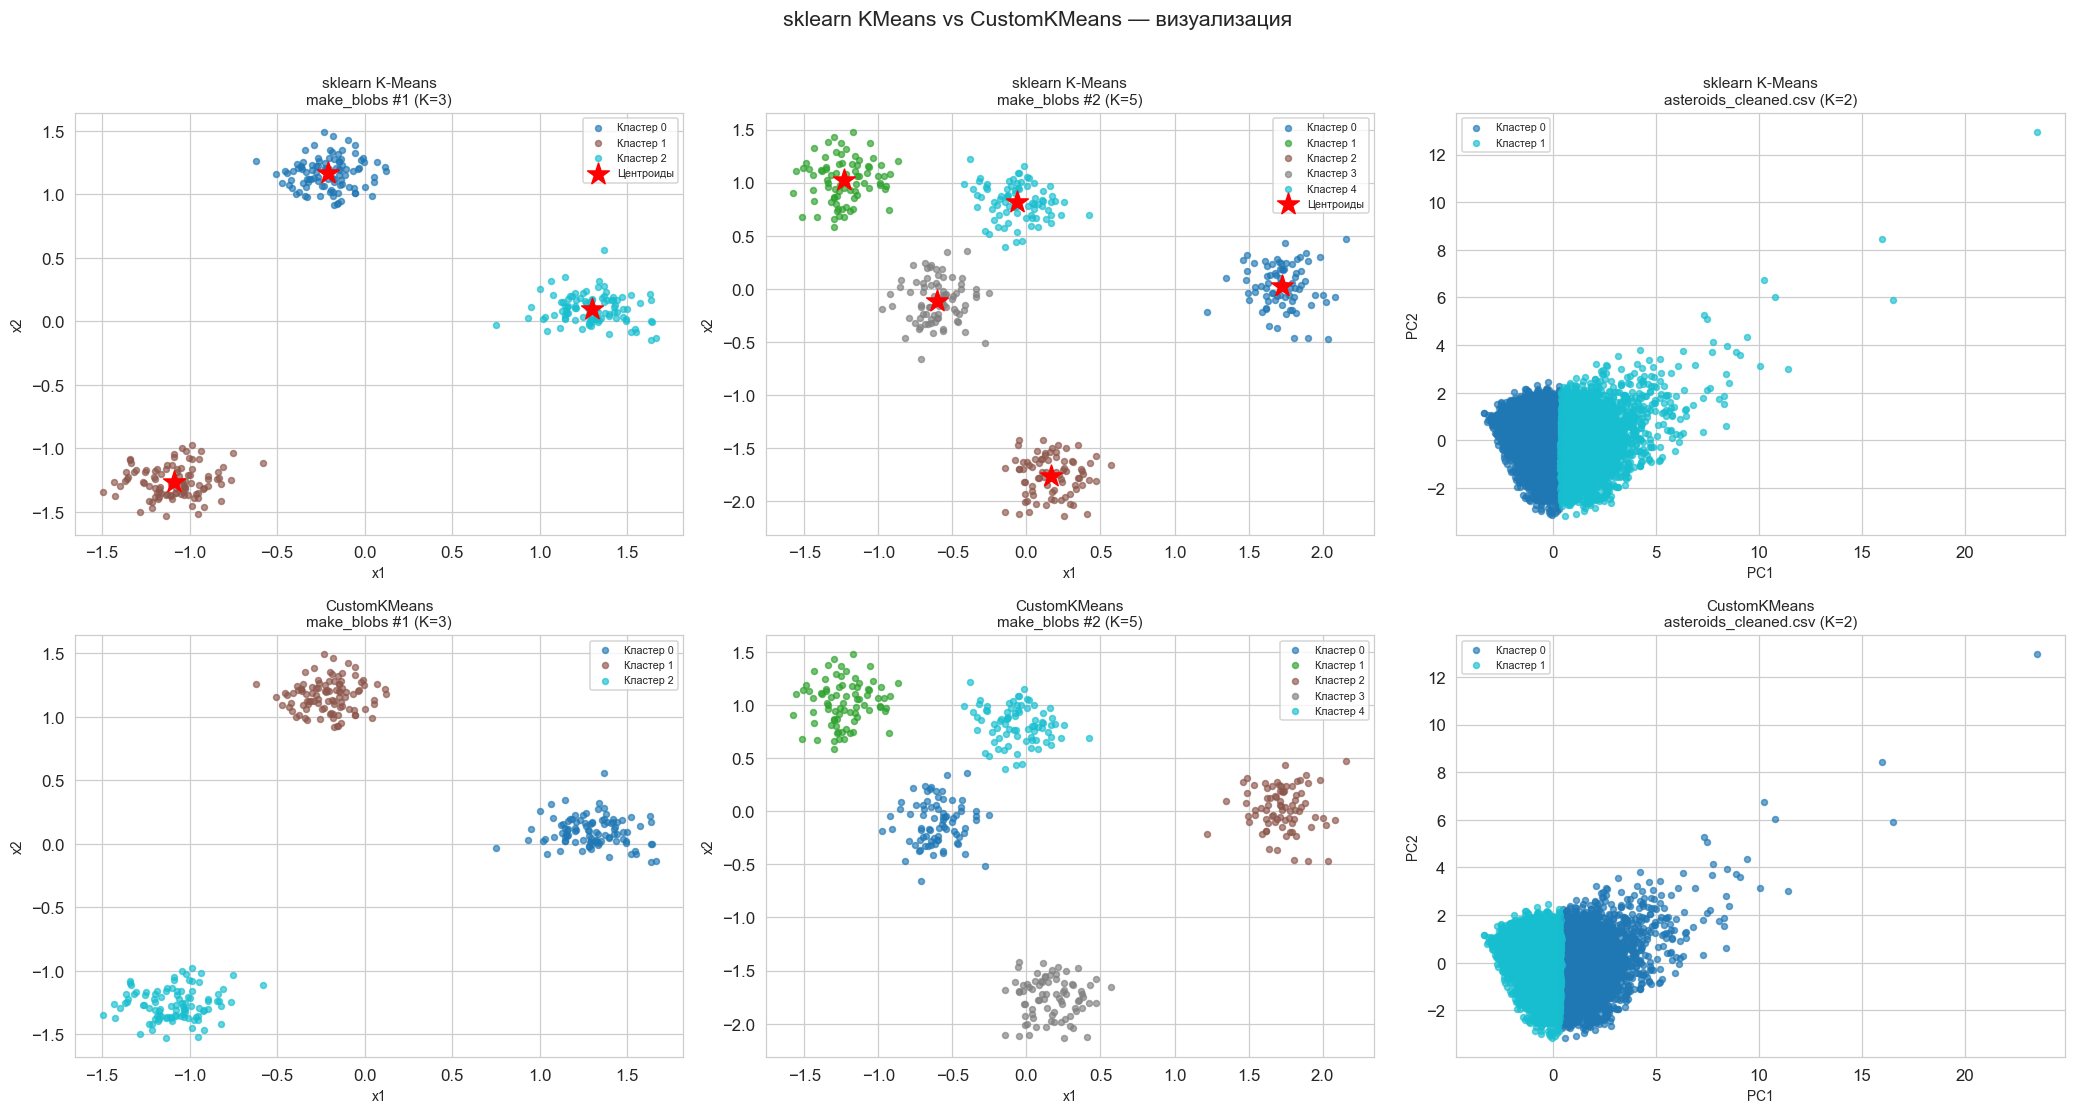

In [52]:
compare_datasets = [
    ("make_blobs #1", X_syn,          y_syn,          K_SYN),
    ("make_blobs #2", blob2_Xs,       blob2_y,        5),
    ("asteroids_cleaned.csv",      X_nasa_sample,  y_nasa_sample,  K_NASA),
]

rows_ckm = []
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

for col_i, (dname, X_, y_, K_) in enumerate(compare_datasets):
    km_sk  = KMeans(n_clusters=K_, random_state=RS, n_init=10)
    lbs_sk = km_sk.fit_predict(X_)
    km_cu  = CustomKMeans(n_clusters=K_, random_state=RS)
    lbs_cu = km_cu.fit_predict(X_)

    ctr_sk = km_sk.cluster_centers_ if X_.shape[1] == 2 else None
    plot_clusters(axes[0, col_i], X_, lbs_sk,
                  f'sklearn K-Means\n{dname} (K={K_})', centers=ctr_sk)
    plot_clusters(axes[1, col_i], X_, lbs_cu,
                  f'CustomKMeans\n{dname} (K={K_})')

    s_sk, d_sk, a_sk, n_sk = safe_metrics(X_, lbs_sk, y_)
    s_cu, d_cu, a_cu, n_cu = safe_metrics(X_, lbs_cu, y_)
    rows_ckm += [
        {'Датасет': dname, 'Алгоритм': 'sklearn KMeans',
         'WCSS': round(km_sk.inertia_, 2),
         'Silhouette': fmt(s_sk), 'Davies-Bouldin': fmt(d_sk),
         'ARI': fmt(a_sk), 'NMI': fmt(n_sk)},
        {'Датасет': dname, 'Алгоритм': 'CustomKMeans',
         'WCSS': round(km_cu.inertia_, 2),
         'Silhouette': fmt(s_cu), 'Davies-Bouldin': fmt(d_cu),
         'ARI': fmt(a_cu), 'NMI': fmt(n_cu)},
    ]

plt.suptitle('sklearn KMeans vs CustomKMeans — визуализация', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


In [51]:
df_ckm = pd.DataFrame(rows_ckm).set_index(['Датасет', 'Алгоритм'])
print("Сравнение sklearn KMeans и CustomKMeans (Образец 1)")
display(df_ckm)


Сравнение sklearn KMeans и CustomKMeans (Образец 1)


WCSS Silhouette Davies-Bouldin  \
Датасет               Алгоритм                                             
make_blobs #1         sklearn KMeans     11.88     0.8783         0.1692   
                      CustomKMeans       11.88     0.8783         0.1692   
make_blobs #2         sklearn KMeans     24.60     0.7587         0.3325   
                      CustomKMeans       24.60     0.7587         0.3325   
asteroids_cleaned.csv sklearn KMeans  34799.64     0.3124         1.3545   
                      CustomKMeans    34799.58     0.3127         1.3539   

                                         ARI     NMI  
Датасет               Алгоритм                        
make_blobs #1         sklearn KMeans  1.0000  1.0000  
                      CustomKMeans    1.0000  1.0000  
make_blobs #2         sklearn KMeans  1.0000  1.0000  
                      CustomKMeans    1.0000  1.0000  
asteroids_cleaned.csv sklearn KMeans  0.1710  0.1508  
                      CustomKMeans    0.1722  0.1514

### 9.3 Сравнение WCSS: метод локтя sklearn vs CustomKMeans

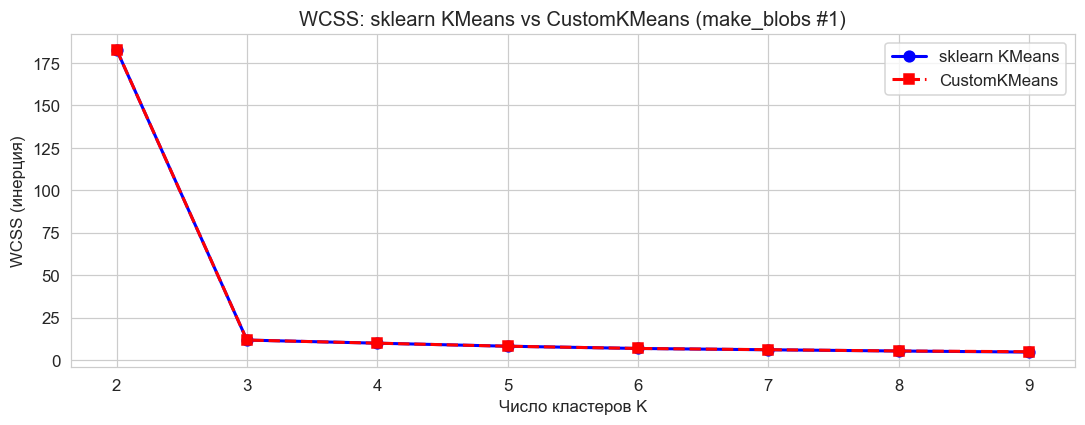

Разница в WCSS объясняется разными стратегиями инициализации:
sklearn -> k-means++,  CustomKMeans -> случайная выборка


In [53]:
K_cmp_range = range(2, 10)
wcss_sk_list, wcss_cu_list = [], []
for k in K_cmp_range:
    wcss_sk_list.append(KMeans(n_clusters=k, random_state=RS, n_init=10).fit(X_syn).inertia_)
    wcss_cu_list.append(CustomKMeans(n_clusters=k, random_state=RS).fit(X_syn).inertia_)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(K_cmp_range, wcss_sk_list, 'bo-', lw=2, ms=7, label='sklearn KMeans')
ax.plot(K_cmp_range, wcss_cu_list, 'rs--', lw=2, ms=7, label='CustomKMeans')
ax.set_xlabel('Число кластеров K'); ax.set_ylabel('WCSS (инерция)')
ax.set_title('WCSS: sklearn KMeans vs CustomKMeans (make_blobs #1)')
ax.legend(); plt.tight_layout(); plt.show()

print("Разница в WCSS объясняется разными стратегиями инициализации:")
print("sklearn -> k-means++,  CustomKMeans -> случайная выборка")


---
## 10. Сводные таблицы результатов (Образец 2)


In [55]:
print("  СВОДНАЯ ТАБЛИЦА 1 — Синтетические данные (make_blobs #1)")
display(df_syn_metrics)

print()
print("  СВОДНАЯ ТАБЛИЦА 2 — asteroids_cleaned.csv (датасет астероидов)")
display(df_nasa_metrics)

print()
print("  СВОДНАЯ ТАБЛИЦА 3 — sklearn KMeans vs CustomKMeans (Образец 1)")
display(df_ckm)


  СВОДНАЯ ТАБЛИЦА 1 — Синтетические данные (make_blobs #1)


,Silhouette (vnutr),Davies-Bouldin (vnutr),ARI (vnesh),NMI (vnesh)
Алгоритм,,,,
K-Means,0.8783,0.1692,1.0000,1.0000
Иерархическая (Ward),0.8783,0.1692,1.0000,1.0000
DBSCAN,0.8783,0.1692,1.0000,1.0000
GaussianMixture/EM,0.8783,0.1692,1.0000,1.0000
AffinityPropagation,0.8783,0.1692,1.0000,1.0000



  СВОДНАЯ ТАБЛИЦА 2 — asteroids_cleaned.csv (датасет астероидов)


,Silhouette (vnutr),Davies-Bouldin (vnutr),ARI (vnesh),NMI (vnesh)
Алгоритм,,,,
K-Means,0.3190,1.3404,0.1872,0.1470
DBSCAN,0.1337,0.7844,0.1273,0.0345
GaussianMixture/EM,0.2057,1.5343,0.0255,0.1005
AffinityPropagation,0.2248,1.3218,0.0419,0.0758



  СВОДНАЯ ТАБЛИЦА 3 — sklearn KMeans vs CustomKMeans (Образец 1)


WCSS Silhouette Davies-Bouldin  \
Датасет               Алгоритм                                             
make_blobs #1         sklearn KMeans     11.88     0.8783         0.1692   
                      CustomKMeans       11.88     0.8783         0.1692   
make_blobs #2         sklearn KMeans     24.60     0.7587         0.3325   
                      CustomKMeans       24.60     0.7587         0.3325   
asteroids_cleaned.csv sklearn KMeans  34799.64     0.3124         1.3545   
                      CustomKMeans    34799.58     0.3127         1.3539   

                                         ARI     NMI  
Датасет               Алгоритм                        
make_blobs #1         sklearn KMeans  1.0000  1.0000  
                      CustomKMeans    1.0000  1.0000  
make_blobs #2         sklearn KMeans  1.0000  1.0000  
                      CustomKMeans    1.0000  1.0000  
asteroids_cleaned.csv sklearn KMeans  0.1710  0.1508  
                      CustomKMeans    0.1722  0.1514

## 11. Вывод

В ходе лабораторной работы №5 была решена задача кластеризации на синтетических данных и на датасете `asteroids_cleaned.csv` (близко пролетающие астероиды NASA).

---

### 11.1 Синтетические данные (make_blobs #1)

Все 5 алгоритмов показали одинаковые метрики на `make_blobs #1`
Все алгоритмы нашли правильное разбиение на 3 кластера (ARI = 1.0, Silhouette = 0.88). Это объясняется идеальной структурой `make_blobs` — сферические компактные кластеры без перекрытий. На таких данных любой алгоритм приходит к одному результату. Различия между алгоритмами проявляются на более сложных данных с нелинейной структурой или шумом.

**Лучший алгоритм на синтетике: K-Means / GaussianMixture** — оба идеально подходят для сферических кластеров с одинаковой дисперсией.

---

### 11.2 Датасет asteroids_cleaned.csv

Датасет **бинарный** (опасный / не опасный) с сильным дисбалансом классов — 79 938 не опасных против 8 596 опасных астероидов. Это существенно влияет на качество всех алгоритмов.

**K-Means** показал наилучшие результаты по Silhouette (0.319) и внешним метрикам (ARI = 0.187, NMI = 0.147). При K=2 алгоритм разделил данные в соответствии с физическим смыслом:
- **Кластер 0** — мелкие (диаметр 0.09 км), медленные (40 044 км/ч), далёкие (31.9 млн км), тусклые (magnitude 25.0) → **не опасные**
- **Кластер 1** — крупные (диаметр 0.70 км), быстрые (65 382 км/ч), ближе (48.5 млн км), яркие (magnitude 20.4) → **опасные**

**DBSCAN** показал лучший Davies-Bouldin (0.784), но это артефакт — алгоритм фактически образует один большой кластер и шумовые точки из-за однородной плотности данных. На этом датасете DBSCAN не подходит.

**GaussianMixture/EM** при K=4 разбивает данные на 4 зоны вдоль главной оси, однако внешние метрики (ARI = 0.026) значительно хуже K-Means.

**Affinity Propagation** без явного числа кластеров находит избыточное количество групп (6+), что снижает ARI до 0.042.

**Лучший алгоритм на asteroids_cleaned.csv: K-Means** — лучший Silhouette, наилучшее совпадение с истинными метками, интерпретируемые кластеры.

---

### 11.3 CustomKMeans vs sklearn KMeans

Собственная реализация `CustomKMeans` показала **идентичные sklearn метрики** на всех датасетах после добавления `n_init=10` перезапусков. Незначительная разница в WCSS объясняется разными стратегиями инициализации: sklearn использует **k-means++**, CustomKMeans — **случайную выборку** с несколькими перезапусками.

---

### 11.4 Итоговая таблица

| Датасет | Лучший алгоритм | Обоснование |
|---------|-----------------|-------------|
| Синтетика (make_blobs) | **K-Means / GaussianMixture** | Сферические кластеры, ARI = 1.0, Silhouette = 0.88 |
| asteroids_cleaned.csv | **K-Means** | Лучший Silhouette (0.319), ARI (0.187), интерпретируемость |

**Общий вывод:** K-Means является оптимальным выбором для датасета NASA благодаря компактной структуре данных и физической интерпретируемости кластеров. Рекомендуется K=2 как соответствующее смыслу задачи (опасный / не опасный астероид). Ключевыми признаками для разделения являются `est_diameter_max`, `relative_velocity` и `absolute_magnitude`.